# Plotting results

The main results we want to show are:
- Comparison between docking score and random selection methods (for both generation methods).
    - For each generation method, a violon plot comparing the docking score distributions per round.
- Comparison between generation methods.
    - Violin plot of the two generation methods' docking score distributions using the docking score selection method.
- Physicochemical properties obtained by the generative methods (docking score selction method), compared to known ligands.
    - Violin plots? Or first, density plots.
- Chemical space exploration by the two generation methods with increasing round number, compared to known ligand space.
    - UMAP of known ligands, and the results of the two generative methods using the docking score selection method, perhaps coloured by round number.
    - Rediscovery of known ligands by ANNalog.

In [1]:
import os
import re
import sys
from itertools import chain

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import MDAnalysis as mda
import numpy as np
import pandas as pd
import prolif as plf
import seaborn as sns
import starbars  # to manually annotate plots with stars for statistical significance - for when statannotations cannot be used
import umap
import umap.plot # required for UMAP plotting functions to work
from matplotlib.patches import (
    Rectangle,  # needed to draw a rectangle in UMAP plots to highlight a zoomed-in region
)
from matplotlib.transforms import ScaledTranslation
from rdkit import Chem
from rdkit.Chem import QED, DataStructs, Descriptors, Draw, rdMolDescriptors
from scipy.stats import ttest_ind  # for statistical testing - independent t-test
from statannotations.Annotator import (
    Annotator,  # for automatic annotation of statistical significance on plots
)

sys.path.append(os.path.join(os.environ['CONDA_PREFIX'],'share','RDKit','Contrib'))
from SA_Score import sascorer


universal_font_size = 14
sns.set_theme(style="white", palette="bright", rc={"font.family": "Arial",
                                                   "font.size": universal_font_size,
                                                   "axes.labelsize": universal_font_size,
                                                   "axes.titlesize": universal_font_size,
                                                   "xtick.labelsize": universal_font_size,
                                                   "ytick.labelsize": universal_font_size,
                                                   "legend.fontsize": universal_font_size,
                                                   "legend.title_fontsize": universal_font_size,
                                                   "legend.frameon": False,
                                                   "figure.autolayout": True,
                                                   "figure.figsize": (5, 5),})
sns.set_style("ticks")


/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)
/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the c

## Setting global directories

In [ ]:
workflow_dir = os.path.join("results", "workflow")

figures_directory = os.path.join("results", "figures")
if not os.path.exists(figures_directory):
    os.makedirs(figures_directory)

## Functions

In [3]:
def create_full_results_df(gen_algo_list:list[str], selection_method_list:list[str]) -> pd.DataFrame:
    """Create a full results DataFrame from the workflow results. This function reads the results from
    the workflow directory and concatenates them into a single DataFrame.

    Args:
        gen_algo_list (list[str]): A list of generation algorithms.
        selection_method_list (list[str]): A list of selection methods.

    Returns:
        pd.DataFrame: A DataFrame containing the full results.
    """
    workflow_dir = os.path.join("results", "workflow")
    
    gen_algo_results_list = []
    for gen_algo in gen_algo_list:
        selection_method_results_list = []
        for selection_method in selection_method_list:
            run_path = os.path.join(workflow_dir, gen_algo, selection_method)
            rounds_list = sorted(os.listdir(run_path))
            if(".DS_Store" in rounds_list): # for whatever reason, .DS_Store might be created on MacOS and read in by listdir
                rounds_list.remove(".DS_Store")
            run_results_list = []
            for round in rounds_list:
                if(selection_method == "random" and round == "round_1"):
                    temp_run_path = os.path.join(workflow_dir, gen_algo, "docking_score") # random selection uses docking_score's round 1.
                    results_path = os.path.join(temp_run_path, round, "clustering", "clustered_results.csv")
                else:
                    results_path = os.path.join(run_path, round, "clustering", "clustered_results.csv")
                print(gen_algo, selection_method, round)
                print(results_path)
                print()
                round_df = pd.read_csv(results_path)
                round_df["round"] = round
                run_results_list.append(round_df)
            run_df = pd.concat(run_results_list, ignore_index=True)
            run_df["selection_method"] = selection_method
            selection_method_results_list.append(run_df)
        selection_methods_df = pd.concat(selection_method_results_list, ignore_index=True)
        selection_methods_df["gen_algo"] = gen_algo
        gen_algo_results_list.append(selection_methods_df)
    results_df = pd.concat(gen_algo_results_list, ignore_index=True)
    return results_df


def calculate_drug_like_properties(smiles: str) -> dict:
    """
    Calculate drug-like properties for a given SMILES string.

    Args:
        smiles (str): The SMILES representation of the molecule.
    Returns:
        dict: A dictionary containing the calculated properties.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")

    properties = {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Arom": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
        "SAScore": sascorer.calculateScore(mol)
    }
    return properties

def add_drug_like_properties_to_df(results_df: pd.DataFrame, smiles_column: str) -> pd.DataFrame:
    drug_like_properties = results_df[smiles_column].apply(calculate_drug_like_properties).apply(pd.Series)
    molecules_with_druglike_props = pd.concat([results_df, drug_like_properties], axis=1)
    return molecules_with_druglike_props

def prep_known_ligands_df(chembl_filepath:str) -> pd.DataFrame:
    """Loads and filters known ligand datafrom ChEMBL-derived .csv files into a dataframe.

    Args:
        chembl_filepath (str): Filepath to the ChEMBL-derived .csv file containing known ligand data.

    Returns:
        pd.DataFrame: A dataframe containing the filtered known ligand data.
    """
    known_ligands_df = pd.read_csv(chembl_filepath, sep=";")
    standard_relation = "'='" # this is being used in the Standard Relation query
    columns_to_keep = ["Molecule ChEMBL ID", "Smiles", "pChEMBL Value", "Standard Type"]
    # filtering the known ligands dataframe to only include potent ligands with a pChEMBL value greater than 7, and only keeping the columns of interest.
    known_ligands_filtered_df = (known_ligands_df.dropna(subset=["pChEMBL Value"])
                .query("`Assay Type` == 'B'")
                .query("`pChEMBL Value` > 7") # only want to consider potent ligands
                .query("`Standard Relation` == @standard_relation")
                .sort_values(by="pChEMBL Value", ascending=False)
                .drop_duplicates(subset=["Smiles"])
                .reset_index(drop=True))
    known_ligands_filtered_df = known_ligands_filtered_df[columns_to_keep]
    known_ligands_filtered_df = add_drug_like_properties_to_df(known_ligands_filtered_df, "Smiles")

    return known_ligands_filtered_df

def return_fingerprint_objects(smiles:str, radius:int=2, fp_size:int=16384, unfolded=False, count=False):
    """
    Generate a Morgan fingerprint for a given SMILES string and return the fingerprint object.

    Args:
        smiles (str): The SMILES representation of the molecule.
        radius (int): The radius parameter for the Morgan fingerprint. Default is 2.
        fp_size (int): The number of bits in the fingerprint. Default is 16384.
        unfolded (bool): Whether to return an unfolded (sparse) fingerprint. Default is False.
        count (bool): Whether to return a count-based fingerprint. Default is False.

    Returns:
        Any: Morgan fingerprint object (either a bit vector or a count vector, depending on the parameters).
    """
    mol = Chem.MolFromSmiles(smiles)
    fpgen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius, fpSize=fp_size)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")
    if((not unfolded) and (not count)):
        fp = fpgen.GetFingerprint(mol)
    elif((not unfolded) and count):
        fp = fpgen.GetCountFingerprint(mol)
    elif(unfolded and (not count)):
        fp = fpgen.GetSparseFingerprint(mol)
    elif(unfolded and count):
        fp = fpgen.GetSparseCountFingerprint(mol)

    return fp

def return_fingerprints(smiles_column:str, radius:int=2, fp_size:int=16384, count=False) -> np.ndarray:
    """
    Generate a Morgan fingerprint for a given SMILES string and return as a numpy array.

    Args:
        smiles (str): The SMILES representation of the molecule.
        radius (int): The radius parameter for the Morgan fingerprint. Default is 2.
        fp_size (int): The number of bits in the fingerprint. Default is 16384.
        count (bool): Whether to return a count-based fingerprint. Default is False.

    Returns:
        np.ndarray: A numpy array representing the Morgan fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles_column)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles_column}")
    fpgen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius, fpSize=fp_size)
    if count:
        fp = fpgen.GetCountFingerprint(mol)
    else:
        fp = fpgen.GetFingerprint(mol)
    fp_arr = np.zeros((0,), dtype=np.int8) # this creates an array of size zero, which is then filled with the fingerprint bits when DataStructs is called.
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    return fp_arr

def return_fingerprints_dataframe(results_df: pd.DataFrame, smiles_column: str, radius: int = 2, fp_size: int = 16384, count = False) -> pd.DataFrame:
    """
    Generate Morgan fingerprints for a DataFrame of SMILES strings.

    Args:
        results_df (pd.DataFrame): The DataFrame containing the SMILES strings.
        smiles_column (str): The name of the column containing the SMILES strings.
        radius (int): The radius parameter for the Morgan fingerprint. Default is 2.
        fp_size (int): The number of bits in the fingerprint. Default is 16384.
        count (bool): Whether to return a count-based fingerprint. Default is False.

    Returns:
        pd.DataFrame: A DataFrame containing the Morgan fingerprints.
    """
    fingerprints = results_df[smiles_column].apply(return_fingerprints, radius=radius, fp_size=fp_size, count=count)
    fingerprints_df = pd.DataFrame(fingerprints.tolist(), index=results_df[smiles_column])
    return fingerprints_df

def save_figure(filename:str):
    plt.savefig(os.path.join(figures_directory, f"{filename}.pdf"), transparent=True, bbox_inches='tight')

def label_figure_subplots(fig: plt.Figure, axs: list[plt.Axes], next_to_title=True):
    """Label subplots with alphabetical labels.

    Args:
        fig (plt.Figure): The figure containing the subplots.
        axs (list[plt.Axes]): The list of axes for the subplots.
        next_to_title (bool, optional): Whether to place the label next to where a subplot title would be (True), otherwise above x-axis labels (False). Defaults to True.
    """
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    figure_labels = [f"{letter})" for letter in alphabet]
    for label, ax in zip(figure_labels, axs):
        if(next_to_title):
            ax.set_title(label, loc='left')
        else:
            ax.text(
                        0.0, 1.0, label, transform=(
                            ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                        fontsize='medium', va='bottom')

def compute_pmf_full_support(df, prop, methods_col="method", round_col="round",
                             support=None):
    """
    Compute PMF for discrete prop over full integer support, per (method, round).

    df: DataFrame with columns [methods_col, round_col, prop]
    prop: name of discrete descriptor column (e.g. 'HBA')
    support: iterable of all integer values to include (e.g. range(0, 12));
             if None, inferred from min/max in df
    """

    if support is None:
        vmin = int(df[prop].min())
        vmax = int(df[prop].max())
        support = np.arange(vmin, vmax + 1)

    # Group by (method, round, prop) to get counts
    counts = (
        df.groupby([methods_col, round_col, prop])
          .size()
          .rename("count")
    )

    # Build full MultiIndex of (method, round, prop) combinations
    methods = counts.index.get_level_values(methods_col).unique()
    rounds = counts.index.get_level_values(round_col).unique()
    full_index = pd.MultiIndex.from_product(
        [methods, rounds, support],
        names=[methods_col, round_col, prop],
    )

    # Reindex to full index, filling missing with 0
    counts_full = counts.reindex(full_index, fill_value=0)

    # Normalise within each (method, round) to get probabilities
    total_per_group = counts_full.groupby([methods_col, round_col]).transform("sum")
    prob = (counts_full / total_per_group).reset_index()
    prob = prob.rename(columns={"count": "prob"})
    prob = prob.dropna() # I believe this removes nonsensical rows created by this method

    return prob

def sort_prolif_resnames(resnames: list) -> list:
    """Sort a list of residue names in ascending order by their residue number.

    Args:
        resnames (list): A list of residue names in the format "RESNUM_RESNAME" (e.g., "ALA123").

    Returns:
        list: A list of residue names sorted by their residue number.
    """
    three_letter_AA_code_pattern = r"(?<=[A-Z]{3})\w+" # grab the residue number after the 3-letter amino acid code
    sorted_resnames = sorted(resnames, key=lambda x: int(re.findall(three_letter_AA_code_pattern, x)[0]))
    return sorted_resnames

def clean_prolif_resname(resname:str) -> str:
    AA_3_to_1_dict = {
        "ALA": "A",
        "ARG": "R",
        "ASN": "N",
        "ASP": "D",
        "CYS": "C",
        "GLN": "Q",
        "GLU": "E",
        "GLY": "G",
        "HIS": "H",
        "ILE": "I",
        "LEU": "L",
        "LYS": "K",
        "MET": "M",
        "PHE": "F",
        "PRO": "P",
        "SER": "S",
        "THR": "T",
        "TRP": "W",
        "TYR": "Y",
        "VAL": "V"
    }
    resname = resname.replace(".A", "")
    three_letter_AA_code_pattern = r"^[A-Z]{3}" #grab the 3-letter amino acid code
    three_letter_AA_code = re.findall(three_letter_AA_code_pattern, resname)[0]
    resname = resname.replace(three_letter_AA_code, AA_3_to_1_dict[three_letter_AA_code])
    return resname


def p_to_stars(p, thresholds=None):
    """
    Convert a p-value to a star string.

    thresholds: list of (threshold, label), checked in ascending order.
    """
    if thresholds is None:
        thresholds = [
            (0.0001, "****"),
            (0.001,  "***"),
            (0.01,   "**"),
            (0.05,   "*"),
        ]
    for thr, lab in thresholds:
        if p <= thr:
            return lab
    return "ns"


def draw_sig_bracket(ax, x1, x2, y_axes, p,
                     linewidth=1.5,
                     color="0.2",
                     cap_height_axes=0.022):
    """
    Draw a significance bracket with x in data coordinates and y in axes coordinates.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axes.
    x1, x2 : float
        Bracket endpoints in x data coordinates.
    y_axes : float
        Vertical position of the top horizontal bar in axes coordinates.
        0 is the bottom spine, 1 is the top spine; values > 1 place
        the bar above the plotting area.
    p : float
        P-value used by p_to_stars(p) if text is not supplied.
    linewidth : float
        Bracket line width.
    color : str
        Bracket and text colour.
    cap_height_axes : float
        Downward length of each vertical cap in axes-coordinate units.
    """
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    
    text = p_to_stars(p)

    y_cap_bottom = y_axes - cap_height_axes

    # Left cap, top bar, right cap
    ax.plot(
        [x1, x1, x2, x2],
        [y_cap_bottom, y_axes, y_axes, y_cap_bottom],
        transform=trans,
        color=color,
        linewidth=linewidth,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y_axes,
        text,
        transform=trans,
        ha="center",
        va="bottom",
        color=color,
        clip_on=False)

## Defining cognate ligand and its properties

In [4]:
class Ligand:
    def __init__(self, smiles, docking_score=None, alpha=None, colour=None):
        self.smiles = Chem.CanonSmiles(smiles)
        self.properties = calculate_drug_like_properties(self.smiles)
        self.docking_score = docking_score
        self.alpha = alpha
        self.colour = colour

cognate_ligand_docking_score = -10.81
cognate_ligand_smiles = "Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5ccccc5"
cognate_ligand = Ligand(cognate_ligand_smiles, docking_score=cognate_ligand_docking_score, alpha=1., colour="lightslategray")

## Defining known ligand dataframe

In [5]:
known_ligands_ki_filepath = os.path.join("known_cb2_ligands", "CHEMBL253_CB2_Homo_sapiens_Ki_140726.csv")
known_ligands_ki_df = prep_known_ligands_df(known_ligands_ki_filepath)
known_ligands_ic50_filepath = os.path.join("known_cb2_ligands", "CHEMBL253_CB2_Homo_sapiens_IC50_170726.csv")
known_ligands_ic50_df = prep_known_ligands_df(known_ligands_ic50_filepath)

known_ligands_filtered_df = pd.concat([known_ligands_ki_df, known_ligands_ic50_df], ignore_index=True)
known_ligands_filtered_df["canon_smiles"] = known_ligands_filtered_df["Smiles"].apply(Chem.CanonSmiles)
known_ligands_filtered_df = (known_ligands_filtered_df
                             .sort_values(by="pChEMBL Value", ascending=False) # higher pChEMBL will be kept for each molecule when duplicates are removed
                             .drop_duplicates(subset=["canon_smiles"]))
known_ligands_filtered_df

,Molecule ChEMBL ID,Smiles,pChEMBL Value,Standard Type,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore,canon_smiles
0,CHEMBL1822945,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12,11.00,Ki,409.486,3.47320,5.0,2.0,93.31,10.0,3.0,0.500266,2.336129,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12
1,CHEMBL1822939,CCCCCc1cc2cc(C(=O)OC)c(=O)[nH]c2c(O)c1OC,10.85,Ki,319.357,2.76160,5.0,2.0,88.62,6.0,2.0,0.631124,2.511687,CCCCCc1cc2cc(C(=O)OC)c(=O)[nH]c2c(O)c1OC
2,CHEMBL600647,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)[...,10.72,Ki,426.488,4.21730,4.0,2.0,80.42,10.0,3.0,0.475943,2.244600,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)[...
3,CHEMBL1822944,CCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12,10.70,Ki,367.405,2.30290,5.0,2.0,93.31,7.0,3.0,0.668346,2.274896,CCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12
4,CHEMBL3410832,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)n...,10.68,Ki,440.515,4.22770,4.0,1.0,69.56,10.0,3.0,0.479288,2.330817,CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)n...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,CHEMBL5868308,CC(C)(C)[C@@H](CO)NC(=O)c1nn(-c2c[n+]([O-])ccn...,7.01,Ki,357.414,0.69710,5.0,2.0,106.98,4.0,2.0,0.618589,4.317761,CC(C)(C)[C@@H](CO)NC(=O)c1nn(-c2c[n+]([O-])ccn...
2085,CHEMBL1909843,Cc1c(C(=O)NCc2ccc(Cl)c(Cl)c2)nn(-c2ccc(Cl)cc2C...,7.01,Ki,528.654,7.16842,2.0,1.0,51.85,5.0,4.0,0.298616,2.703166,Cc1c(C(=O)NCc2ccc(Cl)c(Cl)c2)nn(-c2ccc(Cl)cc2C...
2084,CHEMBL3323673,CCCCCc1cc(O)cc(OCCCCCCCCCCC(=O)N[C@H](C)CO)c1,7.01,Ki,421.622,5.51160,4.0,3.0,78.79,18.0,1.0,0.273040,2.736535,CCCCCc1cc(O)cc(OCCCCCCCCCCC(=O)N[C@H](C)CO)c1
2083,CHEMBL3912660,COc1cc(Nc2cc(Cl)c(S(=O)(=O)NCC3CCCO3)c(Cl)c2)c...,7.01,Ki,461.367,4.21150,6.0,2.0,85.89,8.0,2.0,0.612803,2.871493,COc1cc(Nc2cc(Cl)c(S(=O)(=O)NCC3CCCO3)c(Cl)c2)c...


### Pulling random known ligand for the purposes of future testing.

CCCCCCC(C)(C)c1cc(OC(C)=O)c2c(c1)OC(C)(C)[C@@H]1CC=C(C(=O)O)C[C@@H]21


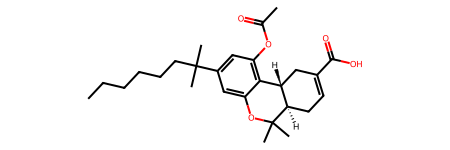

In [6]:
random_known_ligand = known_ligands_filtered_df.sample(1)
random_known_ligand_smiles = random_known_ligand.iloc[0,1]
print(random_known_ligand_smiles)
Chem.MolFromSmiles(random_known_ligand_smiles)

In [7]:
known_ligands_filtered_df["Standard Type"].value_counts()

Standard Type
Ki      2089
IC50     199
Name: count, dtype: int64

In [8]:
gen_algos = ["beam", "sampling"]
selection_methods = ["docking_score", "random"]

In [9]:
full_results_df = add_drug_like_properties_to_df(create_full_results_df(gen_algos, selection_methods), "isomers")
number_of_rounds = len(full_results_df["round"].unique()) # deriving the number of rounds from the full results dataframe, so that it can be used in plotting functions without having to manually input it.
full_results_df.head()

beam docking_score round_1
results/workflow/beam/docking_score/round_1/clustering/clustered_results.csv

beam docking_score round_2
results/workflow/beam/docking_score/round_2/clustering/clustered_results.csv

beam docking_score round_3
results/workflow/beam/docking_score/round_3/clustering/clustered_results.csv

beam docking_score round_4
results/workflow/beam/docking_score/round_4/clustering/clustered_results.csv

beam docking_score round_5
results/workflow/beam/docking_score/round_5/clustering/clustered_results.csv

beam random round_1
results/workflow/beam/docking_score/round_1/clustering/clustered_results.csv

beam random round_2
results/workflow/beam/random/round_2/clustering/clustered_results.csv

beam random round_3
results/workflow/beam/random/round_3/clustering/clustered_results.csv

beam random round_4
results/workflow/beam/random/round_4/clustering/clustered_results.csv

beam random round_5
results/workflow/beam/random/round_5/clustering/clustered_results.csv

sampling dock

,sdf_number,annalog,protonated,isomers,docking_energy,cluster,round,selection_method,gen_algo,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore
0,1,C1C2CC3CC1CC(NC(=O)c1nn(C)c(-c4ccccc4)c1C)(C2)C3,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-11.473,0,round_1,docking_score,beam,349.478,4.09412,2.0,1.0,46.92,3.0,2.0,0.906928,3.612007
1,2,C1C2CC3CC1CC(NC(=O)c1nn(CCCN)c(-c4ccccc4)c1C)(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCC[NH3+])c...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-10.800,0,round_1,docking_score,beam,393.555,3.18912,2.0,2.0,74.56,6.0,2.0,0.790868,4.119554
2,3,C1C2CC3CC1CC(NC(=O)c1nn(CCCCN)c(-c4ccccc4)c1C)...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCC[NH3+])...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-10.885,0,round_1,docking_score,beam,407.582,3.57922,2.0,2.0,74.56,7.0,2.0,0.688605,4.121315
3,4,C1C2CC3CC1CC(NC(=O)c1nn(CCCO)c(-c4ccccc4)c1C)(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCO)c1-c1c...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-10.679,0,round_1,docking_score,beam,393.531,3.93952,3.0,2.0,67.15,6.0,2.0,0.781135,3.708676
4,5,C1C2CC3CC1CC(NC(=O)c1nn(CCCCO)c(-c4ccccc4)c1C)...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCO)c1-c1...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-10.829,0,round_1,docking_score,beam,407.558,4.32962,3.0,2.0,67.15,7.0,2.0,0.671525,3.715831


In [10]:
full_results_df.sort_values(by="docking_energy", ascending=True).head(10)

,sdf_number,annalog,protonated,isomers,docking_energy,cluster,round,selection_method,gen_algo,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore
1654,14,O=C1[C@H]2C[C@H]3C[C@]1(NC(=O)c1cn([C@@H](c4cc...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,-14.580,2,round_5,docking_score,sampling,487.043,6.60382,2.0,1.0,51.10,5.0,3.0,0.441123,5.189567
1540,24,c1(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@H](C2)C4)C...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,-14.387,11,round_4,docking_score,sampling,487.043,6.60382,2.0,1.0,51.10,5.0,3.0,0.441123,5.144555
1541,25,c1(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@H](C2)C4)C...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@@H](C4)C...,-14.335,11,round_4,docking_score,sampling,487.043,6.60382,2.0,1.0,51.10,5.0,3.0,0.441123,5.144555
1580,64,C1[C@H]2C[C@@H]3C[C@@](NC(c4cn(Cc5ccc(F)cc5F)c...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.261,3,round_4,docking_score,sampling,496.548,6.76682,1.0,1.0,34.03,5.0,3.0,0.388967,3.892054
1585,69,C1[C@]2(NC(=O)c3c(C)c(-c4ccc(F)cc4)n(Cc4ccc(F)...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.170,3,round_4,docking_score,sampling,460.568,6.48862,1.0,1.0,34.03,5.0,3.0,0.464028,3.670007
1651,11,[C@@]12(NC(=O)c3c(C)c(-c4ccccc4)n([C@H](Cc4ccc...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@H]2C4)C3...,Cc1c(C(=O)N[C@@]23C[C@@H]4C[C@@H](C[C@H]2C4)C3...,-14.085,57,round_5,docking_score,sampling,452.598,5.75472,2.0,1.0,51.10,6.0,3.0,0.517338,5.156823
1683,43,c1(-c2n(Cc3cc4c(cc3)OCO4)nc(C(N[C@]34C[C@@H]5C...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.072,1,round_5,docking_score,sampling,469.585,5.33412,4.0,1.0,65.38,5.0,3.0,0.548276,3.751348
1696,56,C1[C@]2(NC(=O)c3c(C)c(-c4ccccc4)n(Cc4ccc(F)cc4...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.070,1,round_5,docking_score,sampling,443.566,5.74452,2.0,1.0,46.92,5.0,3.0,0.546216,3.593656
1678,38,c1(F)ccc(Cn2c(-c3ccc(F)cc3)c(C)c(C(=O)N[C@]34C...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.044,7,round_5,docking_score,sampling,478.558,6.62772,1.0,1.0,34.03,5.0,3.0,0.438950,3.788797
1658,18,C(=O)(NC12CC3CC(CC(C3)C1)C2)c1cn(Cc2ccc(F)cc2F...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)cn(Cc2ccc(F)cc...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,-14.022,7,round_5,docking_score,sampling,496.548,6.76682,1.0,1.0,34.03,5.0,3.0,0.388967,3.892054


## Comparison between docking score and random selection methods (for both generation methods).

### Comparison between generation methods.

#### Without significance brackets.

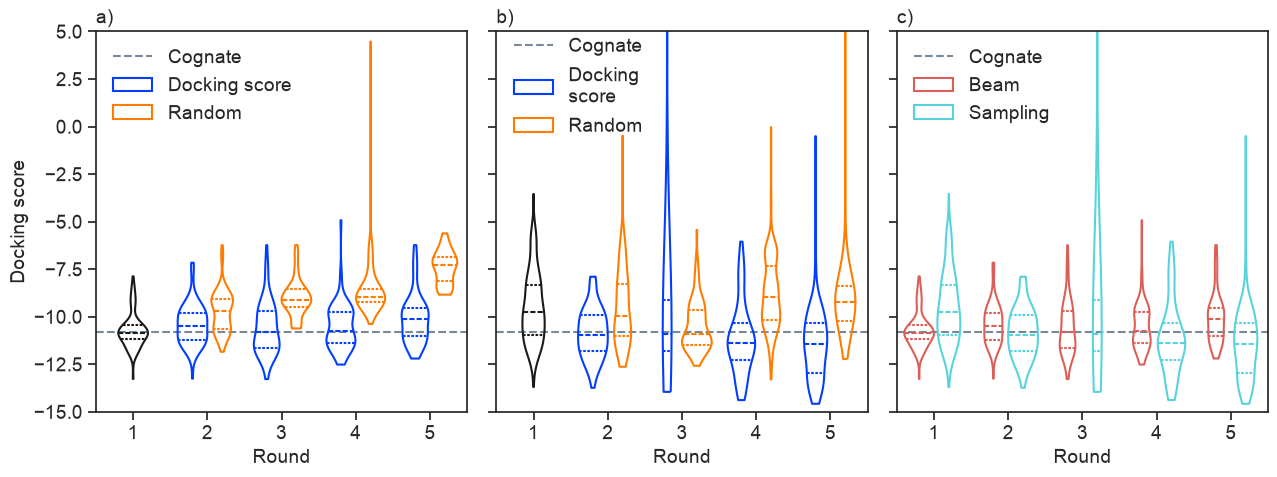

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(13, 5), sharex=True, sharey=True)
axs = axs.flatten()
plt.xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
plt.ylim(-15, 5)

for ax, gen_algo in zip(axs[:2], gen_algos):
    if(gen_algo == "beam"):
        width = 0.4
    elif(gen_algo == "sampling"):
        width = 0.3
    ax.axhline(y=cognate_ligand_docking_score, color=cognate_ligand.colour, linestyle="--", label="Cognate", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
    sns.violinplot(data=full_results_df
                        .query("round == 'round_1'")
                        .query(f"gen_algo == '{gen_algo}'"),
                    x="round",
                    y="docking_energy",
                    inner="quartile",
                    cut=0,
                    fill=False,
                    ax=ax,
                    color="k",
                    width=width)
    sns.violinplot(data=full_results_df
                        .query("round != 'round_1'")
                        .query(f"gen_algo == '{gen_algo}'"),
                    x="round",
                    y="docking_energy",
                    hue="selection_method",
                    inner="quartile",
                    cut=0,
                    fill=False,
                    ax=ax)
    ax.legend_.set_title("") # Remove legend title using _legend attribute
    ax.set_xlabel("Round")
    ax.set_ylabel("Docking score")

# updating subfigure 1 and 2 legends to sentence case and removing legend title
handles, labels = axs[0].get_legend_handles_labels()
labels = [label.replace("_", " ").capitalize() for label in labels]
axs[0].legend(handles, labels)  # Update the legend with sentence case labels
handles, labels = axs[1].get_legend_handles_labels()
labels = [label.replace("_", "\n").capitalize() for label in labels]
axs[1].legend(handles, labels, bbox_to_anchor=(0., 1.03), loc="upper left")  # Update the legend with sentence case labels

# making third subplot
axs[2].axhline(y=cognate_ligand_docking_score, color=cognate_ligand.colour, linestyle="--", label="Cognate", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
sns.violinplot(data=full_results_df.query("selection_method == 'docking_score'"), x="round", y="docking_energy", hue="gen_algo", inner="quartile", cut=0, fill=False, palette="hls", ax=axs[2])
axs[2].legend_.set_title("") # Remove legend title using _legend attribute
handles, labels = axs[2].get_legend_handles_labels()
labels = [label.replace("_", " ").capitalize() for label in labels]
axs[2].legend(handles, labels, loc="upper left")  # Update the legend with sentence case labels
plt.xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
plt.ylim(-15, 5)
plt.xlabel("Round")
plt.ylabel("Docking score")
label_figure_subplots(fig, axs)

# save_figure("docking_score_by_gen_algo_and_selection_method_combined");

#### With significance brackets.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_docking_score vs. round_2_random: t-test independent samples, P_val:4.498e-06 t=-4.703e+00
round_3_docking_score vs. round_3_random: t-test independent samples, P_val:1.046e-16 t=-9.155e+00
round_4_docking_score vs. round_4_random: t-test independent samples, P_val:1.609e-20 t=-1.032e+01
round_5_docking_score vs. round_5_random: t-test independent samples, P_val:4.576e-28 t=-1.364e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_docking_score vs. round_2_random: t-test independent samples, P_val:1.489e-11 t=-6.997e+00
round_3_docking_score vs. round_3_random: t-test independent samples, P_val:1.113e-01 t=1.596e+00
round_4_docking_score v

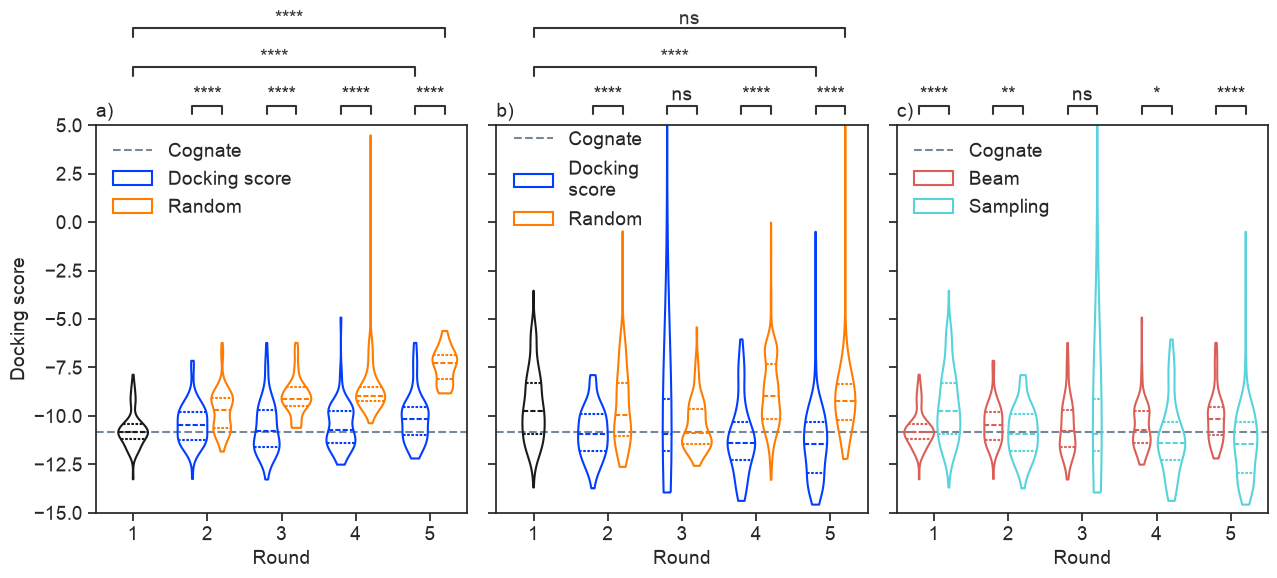

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(13, 6), sharex=True, sharey=True)
axs = axs.flatten()
plt.xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
plt.ylim(-15, 5)

for ax, gen_algo in zip(axs[:2], gen_algos):
    if(gen_algo == "beam"):
        width = 0.4
    elif(gen_algo == "sampling"):
        width = 0.3
    ax.axhline(y=cognate_ligand_docking_score, color=cognate_ligand.colour, linestyle="--", label="Cognate", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
    sns.violinplot(data=full_results_df
                        .query("round == 'round_1'")
                        .query(f"gen_algo == '{gen_algo}'"),
                    x="round",
                    y="docking_energy",
                    inner="quartile",
                    cut=0,
                    fill=False,
                    ax=ax,
                    color="k",
                    width=width)
    sns.violinplot(data=full_results_df
                        .query("round != 'round_1'")
                        .query(f"gen_algo == '{gen_algo}'"),
                    x="round",
                    y="docking_energy",
                    hue="selection_method",
                    inner="quartile",
                    cut=0,
                    fill=False,
                    ax=ax)
    ax.legend_.set_title("") # Remove legend title using _legend attribute
    ax.set_xlabel("Round")
    ax.set_ylabel("Docking score")

    # statistical annotations
    xlabels = [xticklabel.get_text() for xticklabel in ax.get_xticklabels()]
    pairs = [((f"round_{xlabel}", "docking_score"), (f"round_{xlabel}", "random")) for xlabel in xlabels if xlabel != "1"]  # Exclude round 1 from the pairs
    annot = Annotator(ax, pairs, data=full_results_df.query(f"gen_algo == '{gen_algo}'"), x="round", y="docking_energy", hue="selection_method", plot="violinplot")
    annot.configure(test='t-test_ind', text_format='star', loc='outside', verbose=2)
    annot.apply_test()
    annot.annotate()
    # draw significance bracket for round 1 vs round 5 docking_score selection method
    selection_method_to_test = "docking_score"
    round1_round_5_docking_pvalue = ttest_ind(full_results_df.query("round == 'round_1'").query(f"gen_algo == '{gen_algo}'").query(f"selection_method == '{selection_method_to_test}'")["docking_energy"], full_results_df.query("round == 'round_5'").query(f"gen_algo == '{gen_algo}'").query(f"selection_method == '{selection_method_to_test}'")["docking_energy"]).pvalue
    draw_sig_bracket(ax, x1=0, x2=4-0.2, y_axes=1.15, p=round1_round_5_docking_pvalue)
    # draw significance bracket for round 1 vs round 5 random selection method
    selection_method_to_test = "random"
    round1_round_5_random_pvalue = ttest_ind(full_results_df.query("round == 'round_1'").query(f"gen_algo == '{gen_algo}'").query(f"selection_method == '{selection_method_to_test}'")["docking_energy"], full_results_df.query("round == 'round_5'").query(f"gen_algo == '{gen_algo}'").query(f"selection_method == '{selection_method_to_test}'")["docking_energy"]).pvalue
    draw_sig_bracket(ax, x1=0, x2=4+0.2, y_axes=1.25, p=round1_round_5_random_pvalue)

# updating subfigure 1 and 2 legends to sentence case and removing legend title
handles, labels = axs[0].get_legend_handles_labels()
labels = [label.replace("_", " ").capitalize() for label in labels]
axs[0].legend(handles, labels)  # Update the legend with sentence case labels
handles, labels = axs[1].get_legend_handles_labels()
labels = [label.replace("_", "\n").capitalize() for label in labels]
axs[1].legend(handles, labels, bbox_to_anchor=(0., 1.03), loc="upper left")  # Update the legend with sentence case labels

# making third subplot
axs[2].axhline(y=cognate_ligand_docking_score, color=cognate_ligand.colour, linestyle="--", label="Cognate", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
sns.violinplot(data=full_results_df.query("selection_method == 'docking_score'"), x="round", y="docking_energy", hue="gen_algo", inner="quartile", cut=0, fill=False, palette="hls", ax=axs[2])
axs[2].legend_.set_title("") # Remove legend title using _legend attribute
handles, labels = axs[2].get_legend_handles_labels()
labels = [label.replace("_", " ").capitalize() for label in labels]
axs[2].legend(handles, labels, loc="upper left")  # Update the legend with sentence case labels
plt.xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
plt.ylim(-15, 5)
plt.xlabel("Round")
plt.ylabel("Docking score")
label_figure_subplots(fig, axs)

# Annotate the third violin plot with statistical significance stars using statannotations
ax2_xlabels = [xticklabel.get_text() for xticklabel in axs[2].get_xticklabels()]
pairs = [((f"round_{xlabel}", "beam"), (f"round_{xlabel}", "sampling")) for xlabel in ax2_xlabels]
annot = Annotator(axs[2], pairs, data=full_results_df.query("selection_method == 'docking_score'"), x="round", y="docking_energy", hue="gen_algo", plot="violinplot")
annot.configure(test='t-test_ind', text_format='star', loc='outside', verbose=2)
annot.apply_test()
annot.annotate()

save_figure("docking_score_by_gen_algo_and_selection_method_combined");

## Physicochemical properties obtained by the generative methods (docking score selction method), compared to known ligands.

### MW, LogP, TPSA, rotatable bonds QED

/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/147528549.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:3.885e-12 t=-7.293e+00
round_1_beam vs. round_1_sampling: t-test independent samples, P_val:7.097e-05 t=-4.029e+00
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:4.777e-18 t=-9.358e+00
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:3.612e-18 t=-9.565e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:9.163e-33 t=-1.429e+01
1.757094774320278e-52
0.11534990263714705
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:1.359e-01 t=-1.496e+00
round_1_beam vs. round

/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/147528549.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


round_5_beam vs. round_5_sampling: t-test independent samples, P_val:3.407e-13 t=-7.774e+00
2.6492962809171815e-13
0.005476503678051118
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:2.324e-05 t=-4.312e+00


/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/147528549.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


round_1_beam vs. round_1_sampling: t-test independent samples, P_val:3.232e-06 t=-4.745e+00
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:4.341e-18 t=-9.371e+00
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:4.322e-07 t=-5.222e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:9.859e-03 t=-2.605e+00
5.074800982630675e-09
1.683793897455687e-05


/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/147528549.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:9.271e-02 t=-1.688e+00
round_1_beam vs. round_1_sampling: t-test independent samples, P_val:1.517e-01 t=1.437e+00
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:1.550e-10 t=-6.678e+00
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:1.473e-10 t=-6.750e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:9.139e-16 t=-8.713e+00
4.44106273606127e-22
1.6533228881424707e-05
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:1.739e-12 t=7.423e+00
round_1_beam vs. round

/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/147528549.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


round_3_beam vs. round_3_sampling: t-test independent samples, P_val:1.264e-24 t=1.143e+01
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:1.533e-28 t=1.298e+01
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:1.442e-38 t=1.613e+01
8.135349661326052e-61
0.35984877644781754


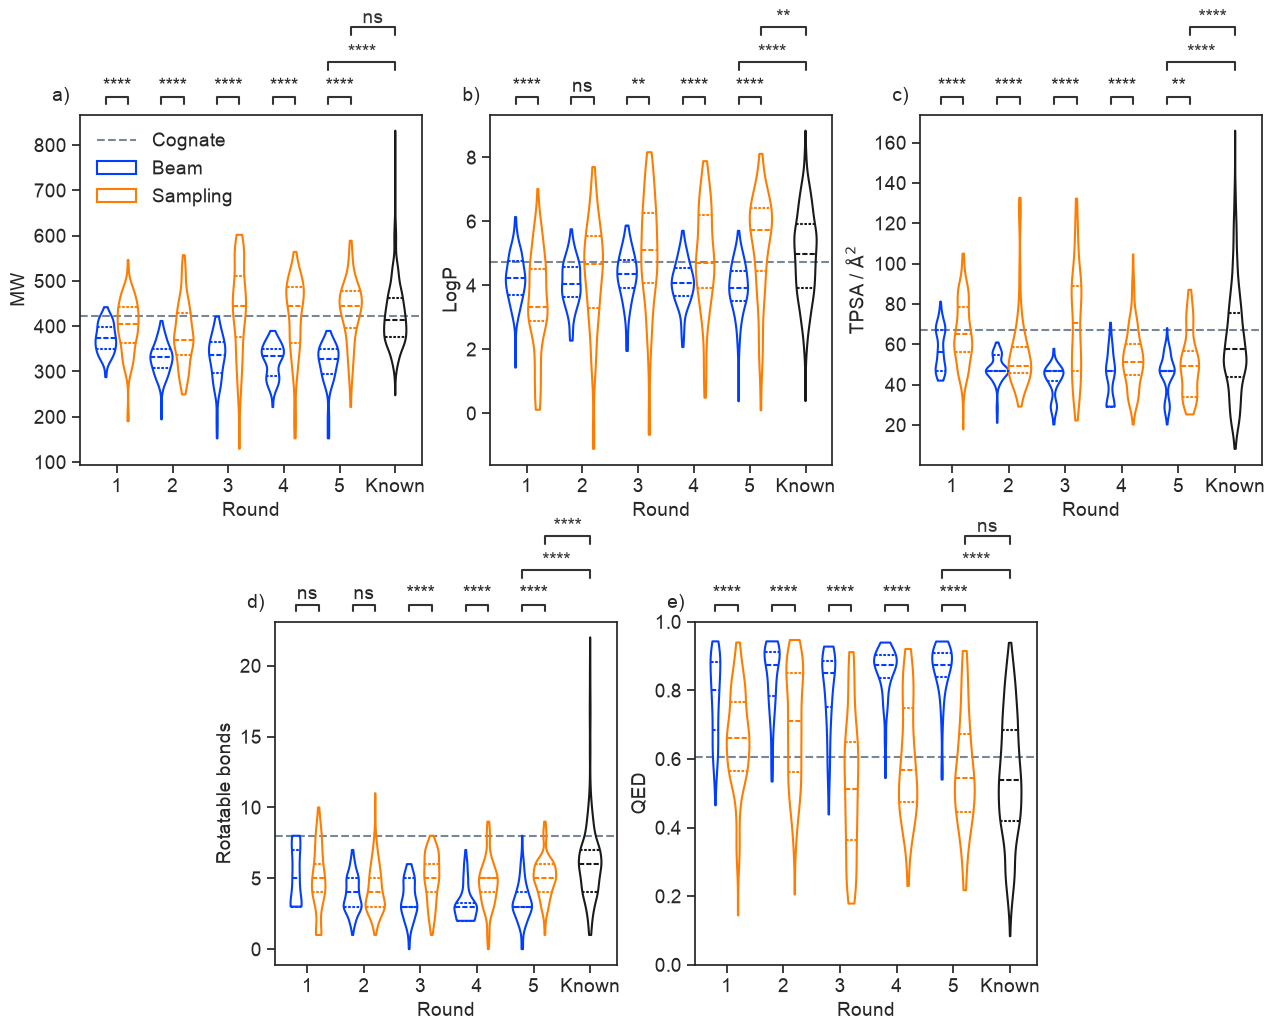

In [13]:
plt.rcParams['figure.autolayout'] = False
drug_like_properties_columns = ["MW", "LogP", "HBA", "HBD", "TPSA", "RotBonds", "Arom", "QED", "SAScore"]
columns_to_keep = ["Smiles"]+drug_like_properties_columns
beam_results_df = (full_results_df
                   .query("gen_algo == 'beam'")
                   .rename(columns={"isomers": "Smiles"})
                   .query("selection_method == 'docking_score'")[columns_to_keep+["round"]])
beam_results_df["method"] = "beam"
sampling_results_df = (full_results_df
                       .query("gen_algo == 'sampling'")
                       .rename(columns={"isomers": "Smiles"})
                       .query("selection_method == 'docking_score'")[columns_to_keep+["round"]])
sampling_results_df["method"] = "sampling"
known_ligands_no_pchembl_df = known_ligands_filtered_df[columns_to_keep]
known_ligands_no_pchembl_df["round"] = "known"
known_ligands_no_pchembl_df["method"] = "known"

known_and_generated_ligands_df = pd.concat([beam_results_df, sampling_results_df, known_ligands_no_pchembl_df], ignore_index=True)

# plotting
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

# MW, LogP, TPSA, RotBonds and SAScore should be represented by violin plots
for i, prop in enumerate(["MW", "LogP", "TPSA", "RotBonds", "QED"]):
    if(prop == "TPSA"):
        axs[i].set_ylabel(r"TPSA / $\rm{\AA^2}$")
    elif(prop == "RotBonds"):
        axs[i].set_ylabel("Rotatable bonds")
    elif(prop == "QED"):
        axs[i].set_ylim(0, 1)
    
    gen_ligands_subset = known_and_generated_ligands_df.copy().query("method != 'known'")  # Filter out known ligands for violin plots
    known_ligands_subset = known_and_generated_ligands_df.copy().query("method == 'known'")  # Filter for known ligands
    axs[i].axhline(y=cognate_ligand.properties[prop], color=cognate_ligand.colour, linestyle="--", label="Cognate", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
    sns.violinplot(x="round", y=prop, data=gen_ligands_subset, ax=axs[i], hue="method", fill=False, cut=0, inner="quartile")
    sns.violinplot(x="round", y=prop, data=known_ligands_subset, ax=axs[i], color="k", fill=False, cut=0, inner="quartile", width=0.4)
    xticklabels = [t.get_text() for t in axs[i].get_xticklabels()]
    axs[i].set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])
    axs[i].set_xlabel("Round")
    if(i != 0):
        axs[i].legend_.remove()  # Remove the legend from all but the first plot to avoid duplication

    # set statistical annotation brackets
    xticklabels_without_known = [t for t in xticklabels if t != "known"]
    pairs = [((xlabel, "beam"), (xlabel, "sampling")) for xlabel in xticklabels_without_known]
    annot = Annotator(x="round", y=prop, data=gen_ligands_subset, ax=axs[i], hue="method", plot="violinplot", pairs=pairs)
    annot.configure(test='t-test_ind', text_format='star', loc='outside', verbose=2)
    annot.apply_test()
    annot.annotate()
    # draw significance bracket for round 1 vs round 5 beam selection method
    gen_method_to_test = "beam"
    round1_round_5_beam_pvalue = ttest_ind(gen_ligands_subset.query("round == 'round_5'").query(f"method == '{gen_method_to_test}'")[prop], known_ligands_subset[prop]).pvalue
    print(round1_round_5_beam_pvalue)
    draw_sig_bracket(axs[i], x1=4-0.2, x2=5, y_axes=1.15, p=round1_round_5_beam_pvalue)
    # draw significance bracket for round 1 vs round 5 sampling selection method
    gen_method_to_test = "sampling"
    round1_round_5_sampling_pvalue = ttest_ind(gen_ligands_subset.query("round == 'round_5'").query(f"method == '{gen_method_to_test}'")[prop], known_ligands_subset[prop]).pvalue
    print(round1_round_5_sampling_pvalue)
    draw_sig_bracket(axs[i], x1=4+0.2, x2=5, y_axes=1.25, p=round1_round_5_sampling_pvalue)

# Set legend labels to titlecase
handles, labels = axs[0].get_legend_handles_labels()
labels = [label.title() for label in labels]
axs[0].legend(handles, labels)

# Removing last subplot as it doesn't contain any information, and moving the fourth and fifth subplots to the middle. The third subplot is also moved slightly to avoid overlap.
axs[-1].set_visible(False)
bottom, width, height = 0.03, 0.228, 0.343
axs[-2].set_position([0.55-0.015,bottom,width,height]) # position is defined as: [left, bottom, width, height] in figure coordinates (0 to 1)
axs[-3].set_position([0.24+0.015,bottom,width,height])
third_subplot_position = axs[2].get_position()
axs[2].set_position([third_subplot_position.x0+0.013, third_subplot_position.y0, third_subplot_position.width, third_subplot_position.height])

label_figure_subplots(fig, axs, next_to_title=False)

save_figure("drug_like_properties_distribution_no_Hbond_for_known_and_generated_ligands")
plt.rcParams['figure.autolayout'] = True


### HBA, HBD and Arom per round

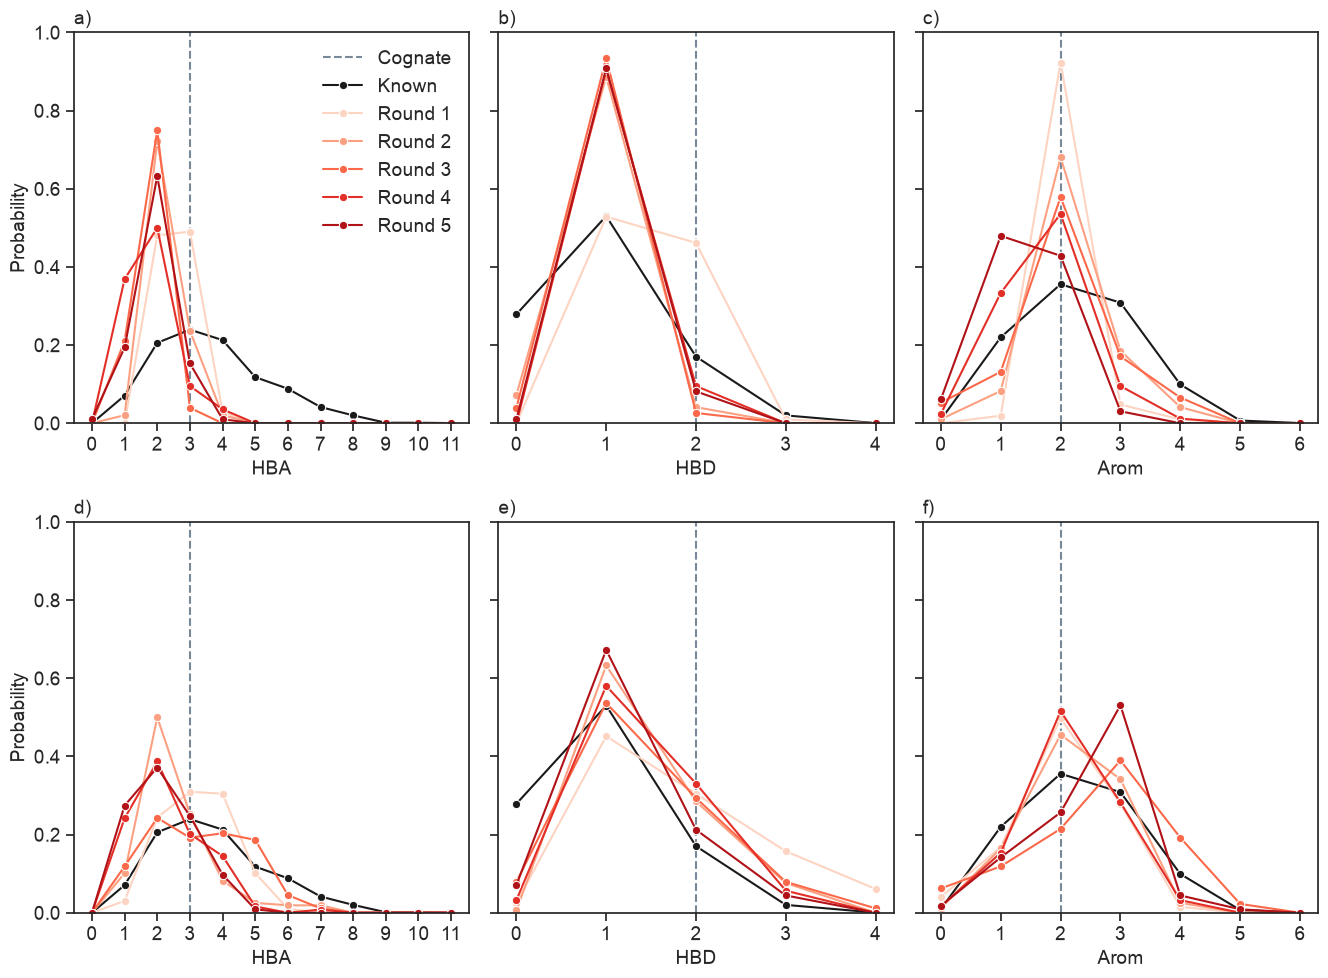

In [14]:
fig, axs = plt.subplots(2, 3 , figsize=(13.5, 10), sharey=True)
palette = "Reds"
for i, prop in enumerate(["HBA", "HBD", "Arom"]):
    
    xmin = int(known_and_generated_ligands_df[prop].min())
    xmax = int(known_and_generated_ligands_df[prop].max())
    for j, (ax, method) in enumerate(zip(axs[:, i], ["beam", "sampling"])):
        if(i == 0):
            ax.set_ylabel("Probability")
        ax.set_xticks(np.arange(xmin, xmax + 1))
        ax.set_ylim(0, 1)
        
        ax.axvline(x=cognate_ligand.properties[prop], color="lightslategray", linestyle="--", label="Cognate", zorder=-50, alpha=1) # cognate ligand reference line
        sns.lineplot(compute_pmf_full_support(known_and_generated_ligands_df, methods_col="method", round_col="round", prop=prop).query("method=='known'"), x=prop, y="prob", markers=True, dashes=False, palette=["k"], hue="round", marker="o", ax=ax)
        sns.lineplot(compute_pmf_full_support(known_and_generated_ligands_df, methods_col="method", round_col="round", prop=prop).query(f"method=='{method}'"), x=prop, y="prob", hue="round", markers=True, dashes=False, marker="o", palette=palette, ax=ax);
        ax.legend(loc="upper right")
        if((i != 0) or (j != 0)):
            ax.legend_.remove()

handles, labels = axs[0,0].get_legend_handles_labels()
labels = [label.replace("_", " ").capitalize() for label in labels]
axs[0,0].legend(handles, labels)  # Update the legend with sentence case labels

label_figure_subplots(fig, axs.flatten())

save_figure("HBA_HBD_Arom_probabilities_for_known_and_generated_ligands")

## SAScore

['round_1', 'round_2', 'round_3', 'round_4', 'round_5']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:8.908e-32 t=-1.354e+01
round_1_beam vs. round_1_sampling: t-test independent samples, P_val:4.175e-11 t=-6.851e+00
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:2.635e-10 t=-6.586e+00
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:1.194e-09 t=-6.373e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:2.020e-03 t=-3.127e+00
6.16 0.03
6.16 0.03


/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/1301160331.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])


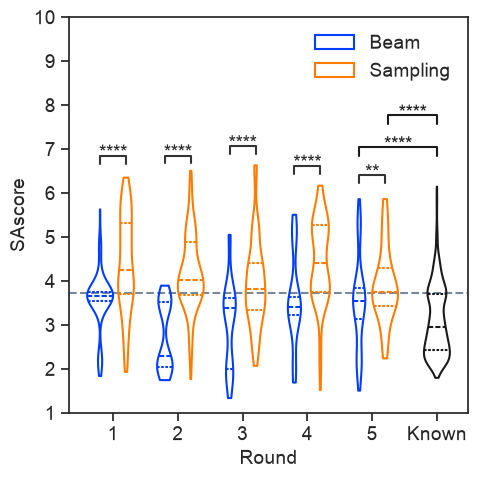

In [15]:
gen_ligands_subset = known_and_generated_ligands_df.copy().query("method != 'known'")  # Filter out known ligands for violin plots
known_ligands_subset = known_and_generated_ligands_df.copy().query("method == 'known'")  # Filter for known ligands
sns.violinplot(x="round", y="SAScore", data=gen_ligands_subset, fill=False, cut=0, inner="quartile", hue="method")
sns.violinplot(x="round", y="SAScore", data=known_ligands_subset, fill=False, cut=0, inner="quartile", color="k", width=0.4)
plt.axhline(y=cognate_ligand.properties["SAScore"], color="lightslategray", linestyle="--", zorder=-50, alpha=cognate_ligand.alpha) # cognate ligand reference line
plt.ylim(1, 10)
ax = plt.gca()
xlabels = [xticklabel.get_text() for xticklabel in ax.get_xticklabels() if "round" in xticklabel.get_text()]
print(xlabels)
pairs = [((xlabel, "beam"), (xlabel, "sampling")) for xlabel in xlabels]

handles, labels = ax.get_legend_handles_labels()
labels = [label.capitalize() for label in labels]
ax.legend(handles, labels)
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticklabels([t.replace("round_", "").capitalize() for t in xticklabels])
plt.xlabel("Round")
plt.ylabel("SAscore")

annot = Annotator(ax, pairs, x="round", y="SAScore", data=gen_ligands_subset, hue="method", plot="violinplot")
annot.configure(test='t-test_ind', text_format='star', loc='inside', verbose=2, text_offset=-5)
annot.apply_test()
annot.annotate(line_offset_to_group=-0.05)

SAscore_beam_known_pvalue = ttest_ind(gen_ligands_subset.query("method=='beam'").query("round == 'round_5'")["SAScore"], known_ligands_subset["SAScore"]).pvalue
SAscore_beam_known_annotations = [(4-0.3, 5+0.1, SAscore_beam_known_pvalue)]
starbars.draw_annotation(SAscore_beam_known_annotations, ax=ax, bar_gap=-0.35, fontsize=universal_font_size, text_distance=0.004, tip_length=0.022)#, top_margin=0)
SAscore_sampling_known_pvalue = ttest_ind(gen_ligands_subset.query("method=='sampling'").query("round == 'round_5'")["SAScore"], known_ligands_subset["SAScore"]).pvalue
SAscore_sampling_known_annotations = [(4+0.15, 5+0.1, SAscore_sampling_known_pvalue)]
starbars.draw_annotation(SAscore_sampling_known_annotations, ax=ax, bar_gap=-0.27, fontsize=universal_font_size, text_distance=0.004, tip_length=0.022)#, top_margin=0)

save_figure("synthetic_accessibility_score_distribution_for_known_and_generated_ligands");

## Rediscovery

In [16]:
# The SMILES in known_and_generated_ligands_df should already be canonical, but just to be safe, I apply Chem.CanonSmiles anyway
known_and_generated_ligands_df["canon_smiles"] = known_and_generated_ligands_df["Smiles"].apply(Chem.CanonSmiles)
known_and_generated_ligands_df.head()

,Smiles,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore,round,method,canon_smiles
0,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,349.478,4.09412,2.0,1.0,46.92,3.0,2.0,0.906928,3.612007,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.555,3.18912,2.0,2.0,74.56,6.0,2.0,0.790868,4.119554,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
2,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.582,3.57922,2.0,2.0,74.56,7.0,2.0,0.688605,4.121315,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
3,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.531,3.93952,3.0,2.0,67.15,6.0,2.0,0.781135,3.708676,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
4,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.558,4.32962,3.0,2.0,67.15,7.0,2.0,0.671525,3.715831,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...


### Exact rediscovery

Looking into exact exact rediscovery.

In [17]:
beam_smiles = set(known_and_generated_ligands_df.query("method == 'beam'")["canon_smiles"])
sampling_smiles = set(known_and_generated_ligands_df.query("method == 'sampling'")["canon_smiles"])
known_ligand_smiles = set(known_and_generated_ligands_df.query("method == 'known'")["canon_smiles"])

print("beam: rediscovered ligands")
print(known_ligand_smiles & beam_smiles)
print("sampling: rediscovered ligands")
print(known_ligand_smiles & sampling_smiles)

beam: rediscovered ligands
set()
sampling: rediscovered ligands
set()


No exact rediscovery.

### Rediscovery - defined now as molecules that have a Tanimoto similarity (ECFP4 - length 16,384) > 0.5

In [18]:
known_ligands_df = known_and_generated_ligands_df.query("method == 'known'").reset_index(drop=True)
known_ligands_fps = known_ligands_df.Smiles.apply(return_fingerprint_objects)
beam_ligands_df = known_and_generated_ligands_df.query("method == 'beam'").reset_index(drop=True)
beam_ligands_fps = beam_ligands_df.Smiles.apply(return_fingerprint_objects)
sampling_ligands_df = known_and_generated_ligands_df.query("method == 'sampling'").reset_index(drop=True)
sampling_ligands_fps = sampling_ligands_df.Smiles.apply(return_fingerprint_objects)

beam_rediscovery_matrix = np.zeros((beam_ligands_fps.shape[0], known_ligands_fps.shape[0]))
sampling_rediscovery_matrix = np.zeros((sampling_ligands_fps.shape[0], known_ligands_fps.shape[0]))

for i, beam_fp in enumerate(beam_ligands_fps.values):
    beam_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(beam_fp, known_ligands_fps.values)
for i, sampling_fp in enumerate(sampling_ligands_fps.values):
    sampling_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(sampling_fp, known_ligands_fps.values)

#### Visualising rediscovery matrix - top=beam, bottom=sampling

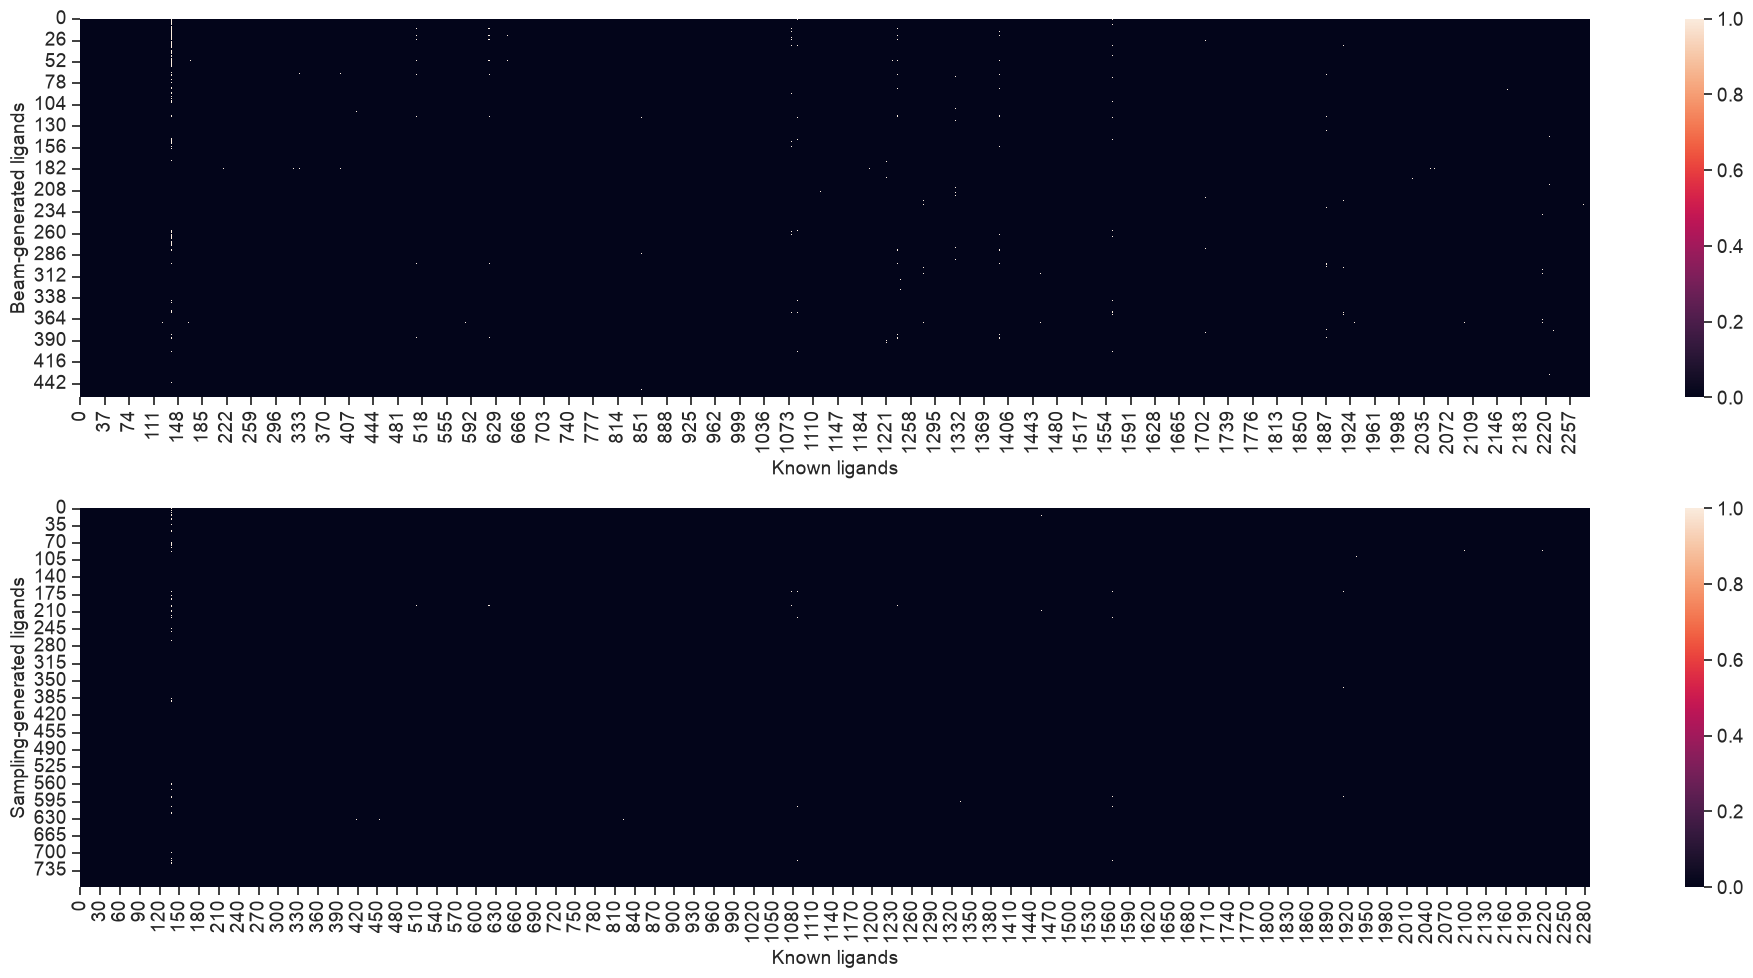

In [19]:
similarity_threshold = 0.5
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
axs = axs.flatten()
sns.heatmap(beam_rediscovery_matrix>similarity_threshold, ax=axs[0])
axs[0].set_xlabel("Known ligands")
axs[0].set_ylabel("Beam-generated ligands")

sns.heatmap(sampling_rediscovery_matrix>similarity_threshold, ax=axs[1])
axs[1].set_xlabel("Known ligands")
axs[1].set_ylabel("Sampling-generated ligands");

### Maximum similarity distributions of generated ligands to known ligands

In [20]:
# defining maximum similarity for beam search
beam_max_sim = beam_rediscovery_matrix.max(axis=1)
beam_max_sim_df = pd.DataFrame({"max_sim" : beam_max_sim})
beam_max_sim_df["method"] = "beam"
beam_max_sim_df["round"] = beam_ligands_df["round"].values

# defining maximum similarity for multinomial sampling
sampling_max_sim = sampling_rediscovery_matrix.max(axis=1)
sampling_max_sim_df = pd.DataFrame({"max_sim" : sampling_max_sim})
sampling_max_sim_df["method"] = "sampling"
sampling_max_sim_df["round"] = sampling_ligands_df["round"].values

# combining the two maximum similarity dataframes into one for plotting with seaborn
combined_max_sim_df = pd.concat([beam_max_sim_df, sampling_max_sim_df])

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:7.658e-13 t=7.555e+00
round_1_beam vs. round_1_sampling: t-test independent samples, P_val:1.841e-26 t=1.175e+01
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:7.850e-25 t=1.149e+01
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:5.498e-07 t=5.171e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:2.268e-06 t=4.863e+00


(<Axes: xlabel='Round', ylabel='Max. Tanimoto similarity (ECFP4)'>,
  <statannotations.Annotation.Annotation at 0x380a27a80>])

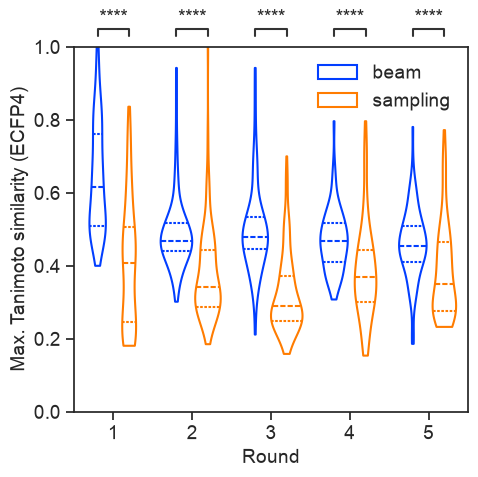

In [21]:
g = sns.violinplot(data=combined_max_sim_df, x="round", y="max_sim", fill=False, cut=0, inner="quartile", hue="method")
plt.ylabel("Max. Tanimoto similarity (ECFP4)")
plt.xlabel("Round")
plt.xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
plt.ylim(0, 1)
plt.legend(title="", loc="upper right")

xlabels = [xticklabel.get_text() for xticklabel in g.get_xticklabels()]
pairs = [((f"round_{xlabel}", "beam"), (f"round_{xlabel}", "sampling")) for xlabel in xlabels]

annot = Annotator(g, pairs, data=combined_max_sim_df, x="round", y="max_sim", hue="method")
annot.configure(test='t-test_ind', text_format='star', loc='outside', verbose=2)
annot.apply_and_annotate()

### Calculating percentage rediscovery

In [22]:
similarity_threshold = 0.5
rounds = [f"round_{i}" for i in range(1, 5+1)]
beam_rediscovery_matrix_by_round = []
sampling_rediscovery_matrix_by_round = []
for round_label in rounds:
    beam_round_df = known_and_generated_ligands_df.query("method == 'beam'").query(f"round == '{round_label}'")
    beam_round_fps = beam_round_df.Smiles.apply(return_fingerprint_objects)
    beam_round_rediscovery_matrix = np.zeros((beam_round_fps.shape[0], known_ligands_fps.shape[0]))
    for i, beam_fp in enumerate(beam_round_fps.values):
        beam_round_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(beam_fp, known_ligands_fps.values)
    beam_round_rediscovery_matrix = beam_round_rediscovery_matrix > similarity_threshold # convert to boolean matrix based on similarity threshold
    beam_round_rediscovery_matrix_df = pd.DataFrame(beam_round_rediscovery_matrix, index=beam_round_df.Smiles.rename("gen_smiles"), columns=known_ligands_df.Smiles.rename("known_smiles"))
    beam_round_rediscovery_matrix_df["method"] = "beam"
    beam_round_rediscovery_matrix_df["round"] = round_label
    beam_rediscovery_matrix_by_round.append(beam_round_rediscovery_matrix_df)

    sampling_round_df = known_and_generated_ligands_df.query("method == 'sampling'").query(f"round == '{round_label}'")
    sampling_round_fps = sampling_round_df.Smiles.apply(return_fingerprint_objects)
    sampling_round_rediscovery_matrix = np.zeros((sampling_round_fps.shape[0], known_ligands_fps.shape[0]))
    for i, sampling_fp in enumerate(sampling_round_fps.values):
        sampling_round_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(sampling_fp, known_ligands_fps.values)
    sampling_round_rediscovery_matrix = sampling_round_rediscovery_matrix > similarity_threshold # convert to boolean matrix based on similarity threshold
    sampling_round_rediscovery_matrix_df = pd.DataFrame(sampling_round_rediscovery_matrix, index=sampling_round_df.Smiles.rename("gen_smiles"), columns=known_ligands_df.Smiles.rename("known_smiles"))
    sampling_round_rediscovery_matrix_df["method"] = "sampling"
    sampling_round_rediscovery_matrix_df["round"] = round_label
    sampling_rediscovery_matrix_by_round.append(sampling_round_rediscovery_matrix_df)

beam_rediscovery_matrix_by_round_df = pd.concat(beam_rediscovery_matrix_by_round, ignore_index=False)   
sampling_rediscovery_matrix_by_round_df = pd.concat(sampling_rediscovery_matrix_by_round, ignore_index=False)
combined_rediscovery_matrix_by_round_df = pd.concat([beam_rediscovery_matrix_by_round_df, sampling_rediscovery_matrix_by_round_df], ignore_index=False)

In [23]:
similarity_threshold = 0.5
rounds = [f"round_{i}" for i in range(1, 5+1)]
beam_rediscovery_matrix_by_round = []
sampling_rediscovery_matrix_by_round = []

for round_label in rounds:
    # --- BEAM ---
    beam_round_df = known_and_generated_ligands_df.query("method == 'beam'").query(f"round == '{round_label}'")
    beam_round_fps = beam_round_df.Smiles.apply(return_fingerprint_objects)
    beam_round_rediscovery_matrix = np.zeros((beam_round_fps.shape[0], known_ligands_fps.shape[0]))
    for i, beam_fp in enumerate(beam_round_fps.values):
        beam_round_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(beam_fp, known_ligands_fps.values)
    beam_round_rediscovery_matrix = (beam_round_rediscovery_matrix > similarity_threshold)

    # MultiIndex columns: level 0 = "known_smiles", level 1 = actual SMILES
    known_cols = pd.MultiIndex.from_product(
        [["known_smiles"], known_ligands_df.Smiles.values],
        names=["super", "known_smiles"]
    )

    beam_round_rediscovery_matrix_df = pd.DataFrame(
        beam_round_rediscovery_matrix,
        index=beam_round_df.Smiles.rename("gen_smiles"),
        columns=known_cols,
    )

    # method/round at same level as "known_smiles" (top level)
    beam_round_rediscovery_matrix_df[("method", "")] = "beam"
    beam_round_rediscovery_matrix_df[("round", "")] = round_label

    beam_rediscovery_matrix_by_round.append(beam_round_rediscovery_matrix_df)

    # --- SAMPLING ---
    sampling_round_df = known_and_generated_ligands_df.query(
        "method == 'sampling'"
    ).query(f"round == '{round_label}'")
    sampling_round_fps = sampling_round_df.Smiles.apply(return_fingerprint_objects)
    sampling_round_rediscovery_matrix = np.zeros(
        (sampling_round_fps.shape[0], known_ligands_fps.shape[0])
    )
    for i, sampling_fp in enumerate(sampling_round_fps.values):
        sampling_round_rediscovery_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(
            sampling_fp, known_ligands_fps.values
        )

    sampling_round_rediscovery_matrix = (
        sampling_round_rediscovery_matrix > similarity_threshold
    )

    sampling_round_rediscovery_matrix_df = pd.DataFrame(
        sampling_round_rediscovery_matrix,
        index=sampling_round_df.Smiles.rename("gen_smiles"),
        columns=known_cols,
    )

    sampling_round_rediscovery_matrix_df[("method", "")] = "sampling"
    sampling_round_rediscovery_matrix_df[("round", "")] = round_label

    sampling_rediscovery_matrix_by_round.append(
        sampling_round_rediscovery_matrix_df
    )

beam_rediscovery_matrix_by_round_df = pd.concat(
    beam_rediscovery_matrix_by_round, ignore_index=False
)
sampling_rediscovery_matrix_by_round_df = pd.concat(
    sampling_rediscovery_matrix_by_round, ignore_index=False
)
combined_rediscovery_matrix_by_round_df = pd.concat(
    [beam_rediscovery_matrix_by_round_df, sampling_rediscovery_matrix_by_round_df],
    ignore_index=False,
)

In [24]:
rediscovery_per_round = combined_rediscovery_matrix_by_round_df.groupby(["method", "round"]).agg("any")
rediscovery_per_round

super                                                 known_smiles  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12   
method   round                                                       
beam     round_1                                             False   
         round_2                                             False   
         round_3                                             False   
         round_4                                             False   
         round_5                                             False   
sampling round_1                                             False   
         round_2                                             False   
         round_3                                             False   
         round_4                                             False   
         round_5                                             False   

super                                                      \
known_smiles     CCCCCc1cc2cc(C(=O)OC)c(=O)[nH]c2c(O)c1OC   
method   round                                              
beam     round_1                                    False   
         round_2                                    False   
         round_3                                    False   
         round_4                                    False   
         round_5                                    False   
sampling round_1                                    False   
         round_2                                    False   
         round_3                                    False   
         round_4                                    False   
         round_5                                    False   

super                                                                  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)[nH]c12   
method   round                                                          
beam     round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                                              False     
         round_5                                              False     
sampling round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                                              False     
         round_5                                              False     

super                                                            \
known_smiles     CCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12   
method   round                                                    
beam     round_1                                          False   
         round_2                                          False   
         round_3                                          False   
         round_4                                          False   
         round_5                                          False   
sampling round_1                                          False   
         round_2                                          False   
         round_3                                          False   
         round_4                                          False   
         round_5                                          False   

super                                                                  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)n(C)c12   
method   round                                                          
beam     round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                   

In [25]:
rediscovery_per_round.agg("sum", axis=1)

method    round  
beam      round_1    36
          round_2    39
          round_3    23
          round_4    34
          round_5    40
sampling  round_1    21
          round_2    23
          round_3     8
          round_4    25
          round_5    22
dtype: int64

In [26]:
df = rediscovery_per_round.sort_index(level=["method", "round"]).copy()

smiles = df["known_smiles"]

cum_seen = smiles.groupby(level="method").cummax()
prev_cum_seen = cum_seen.groupby(level="method").shift(fill_value=False)
first_true = cum_seen & ~prev_cum_seen

already_seen = smiles & ~first_true

# modify in place, then cast
df["known_smiles"] = smiles.mask(already_seen, False).fillna(False).astype(bool)

df_result = df
df_result

super                                                 known_smiles  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12   
method   round                                                       
beam     round_1                                             False   
         round_2                                             False   
         round_3                                             False   
         round_4                                             False   
         round_5                                             False   
sampling round_1                                             False   
         round_2                                             False   
         round_3                                             False   
         round_4                                             False   
         round_5                                             False   

super                                                      \
known_smiles     CCCCCc1cc2cc(C(=O)OC)c(=O)[nH]c2c(O)c1OC   
method   round                                              
beam     round_1                                    False   
         round_2                                    False   
         round_3                                    False   
         round_4                                    False   
         round_5                                    False   
sampling round_1                                    False   
         round_2                                    False   
         round_3                                    False   
         round_4                                    False   
         round_5                                    False   

super                                                                  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)[nH]c12   
method   round                                                          
beam     round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                                              False     
         round_5                                              False     
sampling round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                                              False     
         round_5                                              False     

super                                                            \
known_smiles     CCOc1c(OC)ccc2cc(C(=O)NCCc3ccncc3)c(=O)[nH]c12   
method   round                                                    
beam     round_1                                          False   
         round_2                                          False   
         round_3                                          False   
         round_4                                          False   
         round_5                                          False   
sampling round_1                                          False   
         round_2                                          False   
         round_3                                          False   
         round_4                                          False   
         round_5                                          False   

super                                                                  \
known_smiles     CCCCCOc1c(OC)ccc2cc(C(=O)NCCc3ccc(F)cc3)c(=O)n(C)c12   
method   round                                                          
beam     round_1                                              False     
         round_2                                              False     
         round_3                                              False     
         round_4                   

In [27]:
df_result.agg("sum", axis=1)

method    round  
beam      round_1    36
          round_2    14
          round_3     6
          round_4     4
          round_5     9
sampling  round_1    21
          round_2    10
          round_3     1
          round_4     8
          round_5     1
dtype: int64

Very preliminary plot to confirm that this actually looks sane.

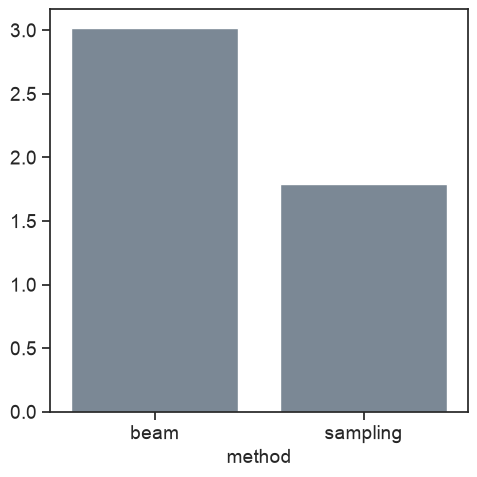

In [28]:
known_ligand_count = known_ligands_df.shape[0]
sns.barplot(rediscovery_per_round.groupby(level="method").agg("any").apply(lambda x: x.sum() / known_ligand_count * 100, axis=1), color="lightslategray");

Looks sane!

Now for the full plot combining the maximum Tanimoto similarity plot with the percentage rediscovery plot

/var/folders/c2/xgvt248n6zz4n7lqzfm6hdsh0000gn/T/ipykernel_9640/2391273291.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(labels)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

round_2_beam vs. round_2_sampling: t-test independent samples, P_val:7.658e-13 t=7.555e+00
round_1_beam vs. round_1_sampling: t-test independent samples, P_val:1.841e-26 t=1.175e+01
round_3_beam vs. round_3_sampling: t-test independent samples, P_val:7.850e-25 t=1.149e+01
round_4_beam vs. round_4_sampling: t-test independent samples, P_val:5.498e-07 t=5.171e+00
round_5_beam vs. round_5_sampling: t-test independent samples, P_val:2.268e-06 t=4.863e+00


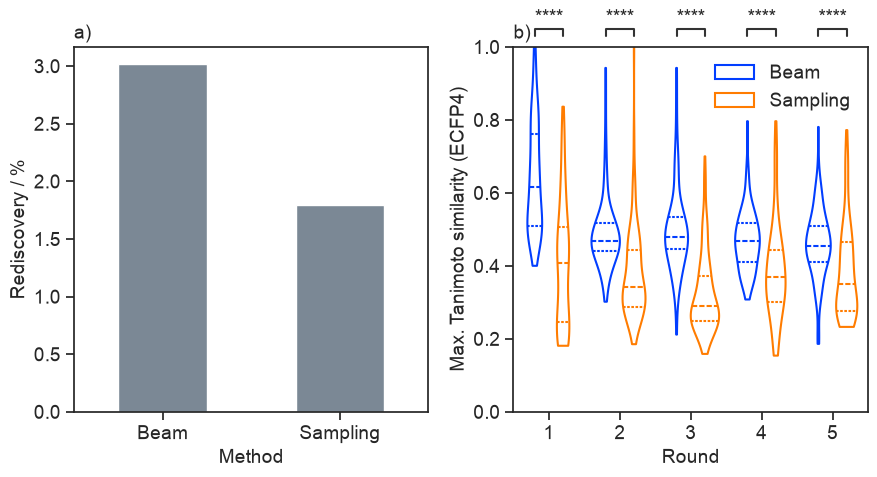

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Plot rediscovery percentage per round for beam and sampling methods
known_ligand_count = known_ligands_df.shape[0]
sns.barplot(rediscovery_per_round.groupby(level="method").agg("any").apply(lambda x: x.sum() / known_ligand_count * 100, axis=1), color="lightslategray", ax=ax1, width=0.5)
ax1.set_ylabel(r"Rediscovery / %")
ax1.set_xlabel("Method")
labels = [item.get_text().capitalize() for item in ax1.get_xticklabels()]
ax1.set_xticklabels(labels)

# Plot maximum Tanimoto similarity distribution per round for beam and sampling methods
beam_max_sim = beam_rediscovery_matrix.max(axis=1)
beam_max_sim_df = pd.DataFrame({"max_sim" : beam_max_sim})
beam_max_sim_df["method"] = "beam"
beam_max_sim_df["round"] = beam_ligands_df["round"].values
sampling_max_sim = sampling_rediscovery_matrix.max(axis=1)
sampling_max_sim_df = pd.DataFrame({"max_sim" : sampling_max_sim})
sampling_max_sim_df["method"] = "sampling"
sampling_max_sim_df["round"] = sampling_ligands_df["round"].values

combined_max_sim_df = pd.concat([beam_max_sim_df, sampling_max_sim_df])
sns.violinplot(data=combined_max_sim_df, x="round", y="max_sim", fill=False, cut=0, inner="quartile", hue="method", ax=ax2)
ax2.set_ylabel("Max. Tanimoto similarity (ECFP4)")
ax2.set_xlabel("Round")
ax2.set_xticks(range(number_of_rounds), np.arange(number_of_rounds)+1)
ax2.set_ylim(0, 1)
handles, labels = ax2.get_legend_handles_labels()
labels = [label.capitalize() for label in labels]
ax2.legend(handles=handles, labels=labels, title="", loc="upper right")

label_figure_subplots(fig, axs=[ax1, ax2])

# statistical annotation for max Tanimoto similarity distribution per round
xlabels = [xticklabel.get_text() for xticklabel in ax2.get_xticklabels()]
pairs = [((f"round_{xlabel}", "beam"), (f"round_{xlabel}", "sampling")) for xlabel in xlabels]
annot = Annotator(ax2, pairs, data=combined_max_sim_df, x="round", y="max_sim", hue="method", plot="violinplot")
annot.configure(test='t-test_ind', text_format='star', loc='outside', verbose=2)
annot.apply_and_annotate()

save_figure("rediscovery_percentage_and_max_tanimoto_similarity_distribution_for_known_and_generated_ligands_per_round");

## UMAP - chemical space exploration visualisation

In [30]:
class umap_data: # used just for keeping together data for UMAP plotting, not for UMAP computation
    def __init__(self, df, smiles_column="Smiles", radius=2, fp_size=2048):
        self.smiles = df[smiles_column].to_list()
        self.target = df["method"]
        self.fingerprints = return_fingerprints_dataframe(df, smiles_column, radius, fp_size).values

cognate_ligand_df = pd.DataFrame({"Smiles": [cognate_ligand.smiles],
                                  "MW": [cognate_ligand.properties["MW"]],
                                  "LogP": [cognate_ligand.properties["LogP"]],
                                  "HBA": [cognate_ligand.properties["HBA"]],
                                  "HBD": [cognate_ligand.properties["HBD"]],
                                  "TPSA": [cognate_ligand.properties["TPSA"]],
                                  "Arom": [cognate_ligand.properties["Arom"]],
                                  "RotBonds": [cognate_ligand.properties["RotBonds"]],
                                  "QED": [cognate_ligand.properties["QED"]],
                                  "SAScore": [cognate_ligand.properties["SAScore"]],
                                  "round": ["cognate"],
                                  "method": ["cognate"],
                                  "canon_smiles": [Chem.CanonSmiles(cognate_ligand.smiles)]})

known_generated_and_cognate_ligands_df = pd.concat([known_and_generated_ligands_df, cognate_ligand_df], ignore_index=True)
known_and_generated_ligands_data = umap_data(known_generated_and_cognate_ligands_df, smiles_column="Smiles", radius=2, fp_size=2048)

Testing built-in UMAP plotting. Not a big fan, personally.

/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


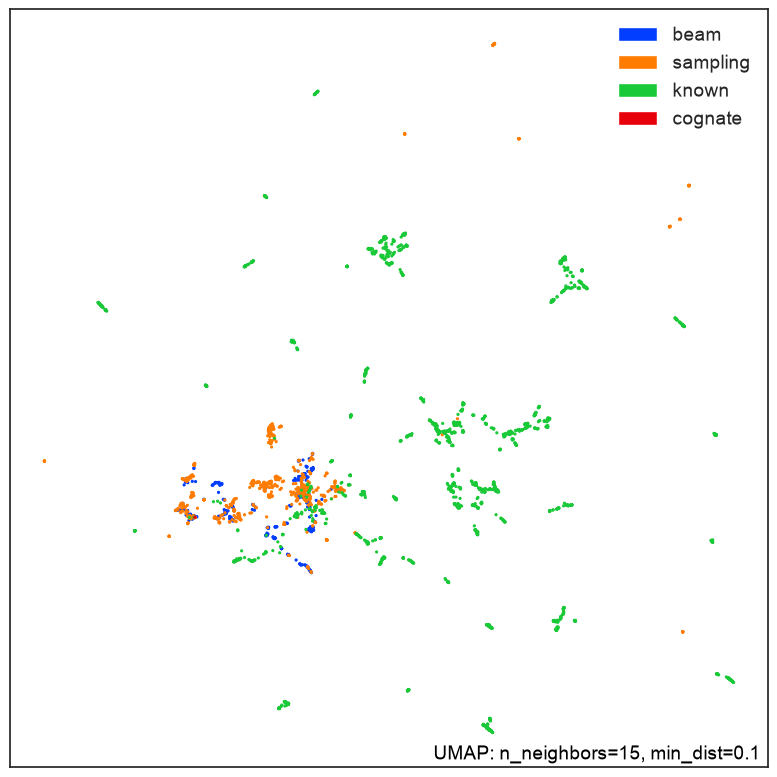

In [31]:
mapper = umap.UMAP(random_state=42).fit(known_and_generated_ligands_data.fingerprints)
methods = known_and_generated_ligands_data.target.unique()
color_key_cmap = dict(zip(methods, sns.color_palette()[:len(methods)]))
ax = umap.plot.points(mapper, labels=known_and_generated_ligands_data.target, color_key=color_key_cmap)

# Existing legend handles/labels
legend = ax.get_legend()
labels = [t.get_text() for t in legend.get_texts()]
handles = legend.legend_handles

# Use your desired order (methods) to reorder
label_to_handle = {lab: h for lab, h in zip(labels, handles)}

# reorder handles and labels according to the order in methods
ordered_handles = [label_to_handle[lab] for lab in methods]
ordered_labels = list(methods)

# Set the legend with the new order
ax.legend(ordered_handles, ordered_labels)
# save_figure("umap_projection_of_known_and_generated_ligands");

Now plotting in a nice way, using the `embedding_` attribute of the UMAP mapper object to derive the points for plotting chemical space.

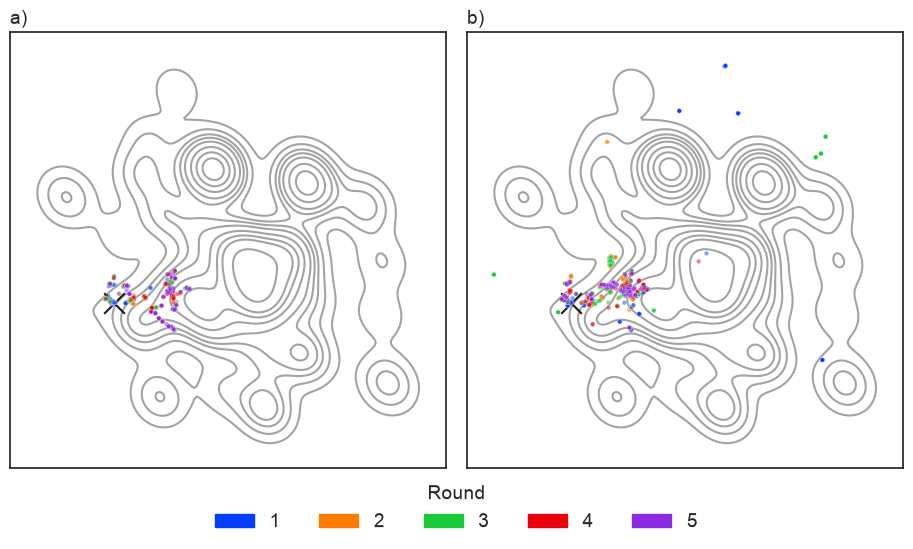

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(9.35, 5))
axs = axs.flatten()
# known ligands
known_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'known'").index
sampling_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'sampling'").index
beam_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'beam'").index

scatterplot_alpha = 0.5
scatterplot_point_size = 10
kdeplot_alpha = 0.4

# known ligand background
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[0], alpha=kdeplot_alpha)
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[1], alpha=kdeplot_alpha)

# cognate ligand point
cognate_ligand_index = known_generated_and_cognate_ligands_df.query("method == 'cognate'").index
axs[0].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)
axs[1].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)

# beam-generated ligands
sns.scatterplot(x=mapper.embedding_[beam_ligand_indices, 0], y=mapper.embedding_[beam_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_ligand_indices]["round"], s=scatterplot_point_size, ax=axs[0], alpha=scatterplot_alpha)

# sampling-generated ligands
sns.scatterplot(x=mapper.embedding_[sampling_ligand_indices, 0], y=mapper.embedding_[sampling_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_ligand_indices]["round"], s=scatterplot_point_size, ax=axs[1], alpha=scatterplot_alpha)

# Making the legend prettier
axs[0].legend_.remove()  # Remove the legend from the first plot to avoid duplication
legend_handles, legend_labels = axs[1].get_legend_handles_labels()
legend_labels = [label.replace("round_", "") for label in legend_labels]  # Clean up labels
# Create square patches for the legend to replace the tiny circles
square_handles = []
for h, l in zip(legend_handles, legend_labels):
    if hasattr(h, "get_color"):  # Line2D
        c = h.get_color()
    else:  # Patch / other artists
        c = h.get_facecolor()
    square_handles.append(mpatches.Patch(facecolor=c, edgecolor=c, label=l))

# axs[1].legend(square_handles, legend_labels, title="Round", loc="upper right", bbox_to_anchor=(1.25, 1))
axs[1].legend_.remove()
axs[0].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
axs[1].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

# axs[0].set_title("Beam-generated ligands")
# axs[1].set_title("Sampling-generated ligands")
fig.legend(handles=square_handles, labels=legend_labels, title="Round", loc="lower center", bbox_to_anchor=(0.5, -0.12), ncols=5)

label_figure_subplots(fig, axs)

save_figure("umap_projection_of_known_and_generated_ligands_by_round");

### Chemical space plot highlighting generation candidates.

In [33]:
# Identifying generation candidates for each round
gen_candidates_boolean_mask = np.zeros(known_generated_and_cognate_ligands_df.shape[0], dtype=bool) # boolean mask for generation candidates
gen_molecule_subset_df = known_generated_and_cognate_ligands_df.query("method == 'beam' | method == 'sampling'").copy()
len_of_gen_molecules = gen_molecule_subset_df.shape[0]
relevant_boolean_mask_section = gen_candidates_boolean_mask[:len_of_gen_molecules]

# Create a dictionary to store the generation candidates for each method and round
gen_candidates_beam_and_sampling_dict = {}
for method in ["beam", "sampling"]:
    gen_candidates_smiles_per_round = {}
    for round_num in range(1, 6):
        round_label = f"round_{round_num}"
        gen_candidates_path = os.path.join(workflow_dir, method, "docking_score", round_label, "clustering", "generation_candidates.csv")
        gen_candidates = pd.read_csv(gen_candidates_path).smiles.to_list()
        gen_candidates_smiles_per_round[round_label] = gen_candidates

    gen_candidates_beam_and_sampling_dict[method] = gen_candidates_smiles_per_round

# set the boolean mask for each generation candidate
for method in ["beam", "sampling"]:
    for round_num in range(1, 5): # round 5 is not included because it is the final round and does not have any relevant generation candidates
        round_label = f"round_{round_num}"
        gen_molecule_subset_df_round = gen_molecule_subset_df.query(f"method == '{method}' & round == 'round_{round_num}'")
        gen_candidates_smiles = gen_candidates_beam_and_sampling_dict[method][round_label]
        gen_candidates_mask = gen_molecule_subset_df_round["canon_smiles"].isin(gen_candidates_smiles)
        relevant_indices = gen_molecule_subset_df_round.index[gen_candidates_mask]
        gen_candidates_boolean_mask[relevant_indices] = True

# Create DataFrames for generation candidates and non-candidates
gen_candidates_df = known_generated_and_cognate_ligands_df[gen_candidates_boolean_mask].copy()
gen_candidate_indices = gen_candidates_df.index
not_gen_candidates_df = known_generated_and_cognate_ligands_df[~gen_candidates_boolean_mask].copy()
non_gen_candidate_indices = not_gen_candidates_df.index

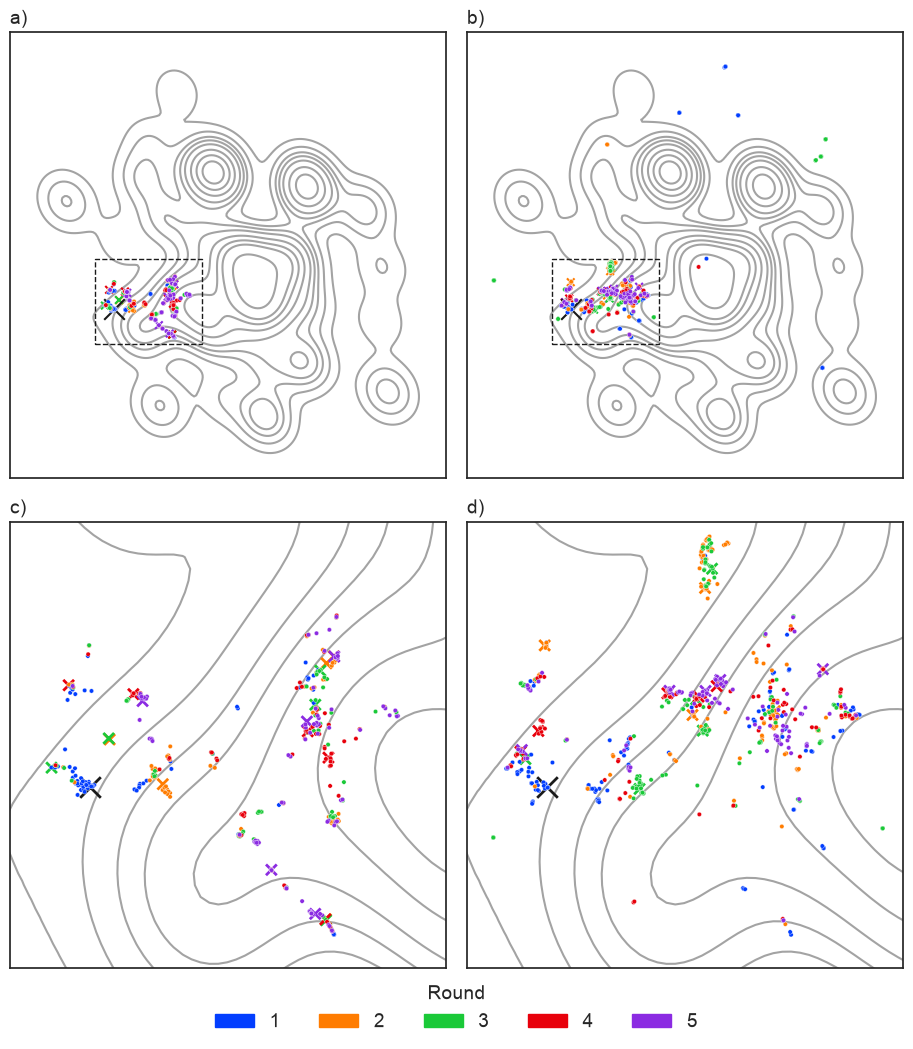

In [34]:
# plotting
fig, axs = plt.subplots(2, 2, figsize=(9.35, 10))
axs = axs.flatten()
# known ligands
known_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'known'").index
# sampling ligands
sampling_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'sampling'").index
sampling_gen_candidate_indices = sorted(set(sampling_ligand_indices) & set(gen_candidate_indices))
sampling_non_gen_candidate_indices = sorted(set(sampling_ligand_indices) - set(gen_candidate_indices))
# beam ligands
beam_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'beam'").index
beam_gen_candidate_indices = sorted(set(beam_ligand_indices) & set(gen_candidate_indices))
beam_non_gen_candidate_indices = sorted(set(beam_ligand_indices) - set(gen_candidate_indices))

scatterplot_alpha = 1.
scatterplot_point_size = 10
kdeplot_alpha = 0.4
shifted_palette_for_gen_candidates = sns.color_palette()[1:][:4]

# known ligand background
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[0], alpha=kdeplot_alpha)
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[1], alpha=kdeplot_alpha)

# cognate ligand point
cognate_ligand_index = known_generated_and_cognate_ligands_df.query("method == 'cognate'").index
axs[0].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)
axs[1].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)

# beam-generated ligands
sns.scatterplot(x=mapper.embedding_[beam_non_gen_candidate_indices, 0], y=mapper.embedding_[beam_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[0], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[beam_gen_candidate_indices, 0], y=mapper.embedding_[beam_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_gen_candidate_indices]["round"], s=scatterplot_point_size*3, ax=axs[0], marker="x", linewidth=1.5, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# sampling-generated ligands
sns.scatterplot(x=mapper.embedding_[sampling_non_gen_candidate_indices, 0], y=mapper.embedding_[sampling_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[1], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[sampling_gen_candidate_indices, 0], y=mapper.embedding_[sampling_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_gen_candidate_indices]["round"], s=scatterplot_point_size*3, ax=axs[1], marker="x", linewidth=1.5, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# zoomed in plots
zoom_in_cross_linewidth = 2.0
zoom_in_xmin, zoom_in_xmax = -13, -2
zoom_in_ymin, zoom_in_ymax = -3, 6
for i in [2,3]:
    axs[i].set_xlim(zoom_in_xmin, zoom_in_xmax)
    axs[i].set_ylim(zoom_in_ymin, zoom_in_ymax)
# known ligand background
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[2], alpha=kdeplot_alpha)
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[3], alpha=kdeplot_alpha)

# cognate ligand point
cognate_ligand_index = known_generated_and_cognate_ligands_df.query("method == 'cognate'").index
axs[2].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=zoom_in_cross_linewidth)
axs[3].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=zoom_in_cross_linewidth)

# beam-generated ligands
sns.scatterplot(x=mapper.embedding_[beam_non_gen_candidate_indices, 0], y=mapper.embedding_[beam_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[2], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[beam_gen_candidate_indices, 0], y=mapper.embedding_[beam_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_gen_candidate_indices]["round"], s=scatterplot_point_size*6, ax=axs[2], marker="x", linewidth=zoom_in_cross_linewidth, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# sampling-generated ligands
sns.scatterplot(x=mapper.embedding_[sampling_non_gen_candidate_indices, 0], y=mapper.embedding_[sampling_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[3], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[sampling_gen_candidate_indices, 0], y=mapper.embedding_[sampling_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_gen_candidate_indices]["round"], s=scatterplot_point_size*6, ax=axs[3], marker="x", linewidth=zoom_in_cross_linewidth, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# draw dashed line around the zoomed in area in the first two plots
zoom_in_width = zoom_in_xmax - zoom_in_xmin
zoom_in_height = zoom_in_ymax - zoom_in_ymin
for ax in axs[:2]:
    zoom_in_square = Rectangle( (zoom_in_xmin, zoom_in_ymin), zoom_in_width, zoom_in_height, linestyle = 'dashed', facecolor = 'None', edgecolor="k", zorder=-40)
    ax.add_patch(zoom_in_square)

# Making the legend prettier
legend_handles, legend_labels = axs[1].get_legend_handles_labels()
legend_handles, legend_labels = legend_handles[:5], legend_labels[:5]  # Keep only the first 5 handles and labels
legend_labels = [label.replace("round_", "") for label in legend_labels]  # Clean up labels
# Create square patches for the legend to replace the tiny circles
square_handles = []
for h, l in zip(legend_handles, legend_labels):
    if hasattr(h, "get_color"):  # Line2D
        c = h.get_color()
    else:  # Patch / other artists
        c = h.get_facecolor()
    square_handles.append(mpatches.Patch(facecolor=c, edgecolor=c, label=l))

for ax in axs:
    ax.legend_.remove()
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

fig.legend(handles=square_handles, labels=legend_labels, title="Round", loc="lower center", bbox_to_anchor=(0.5, -0.06), ncols=5)

label_figure_subplots(fig, axs)

save_figure("umap_projection_of_known_and_generated_ligands_by_round_with_gen_candidates_highlighted");

#### The above plot but without dashed rectangle (for thesis presentation)

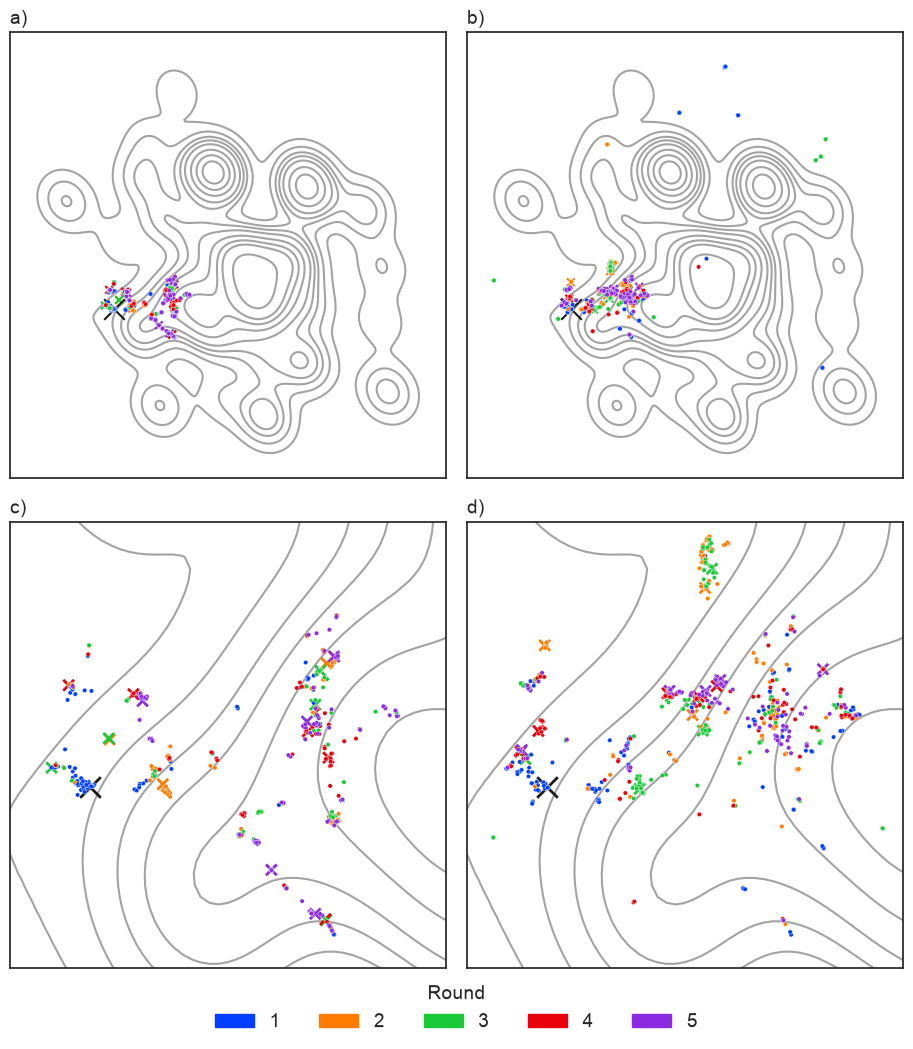

In [35]:
# plotting
fig, axs = plt.subplots(2, 2, figsize=(9.35, 10))
axs = axs.flatten()
# known ligands
known_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'known'").index
# sampling ligands
sampling_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'sampling'").index
sampling_gen_candidate_indices = sorted(set(sampling_ligand_indices) & set(gen_candidate_indices))
sampling_non_gen_candidate_indices = sorted(set(sampling_ligand_indices) - set(gen_candidate_indices))
# beam ligands
beam_ligand_indices = known_generated_and_cognate_ligands_df.query("method == 'beam'").index
beam_gen_candidate_indices = sorted(set(beam_ligand_indices) & set(gen_candidate_indices))
beam_non_gen_candidate_indices = sorted(set(beam_ligand_indices) - set(gen_candidate_indices))

scatterplot_alpha = 1.
scatterplot_point_size = 10
kdeplot_alpha = 0.4
shifted_palette_for_gen_candidates = sns.color_palette()[1:][:4]

# known ligand background
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[0], alpha=kdeplot_alpha)
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[1], alpha=kdeplot_alpha)

# cognate ligand point
cognate_ligand_index = known_generated_and_cognate_ligands_df.query("method == 'cognate'").index
axs[0].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)
axs[1].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=1.5)

# beam-generated ligands
sns.scatterplot(x=mapper.embedding_[beam_non_gen_candidate_indices, 0], y=mapper.embedding_[beam_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[0], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[beam_gen_candidate_indices, 0], y=mapper.embedding_[beam_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_gen_candidate_indices]["round"], s=scatterplot_point_size*3, ax=axs[0], marker="x", linewidth=1.5, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# sampling-generated ligands
sns.scatterplot(x=mapper.embedding_[sampling_non_gen_candidate_indices, 0], y=mapper.embedding_[sampling_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[1], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[sampling_gen_candidate_indices, 0], y=mapper.embedding_[sampling_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_gen_candidate_indices]["round"], s=scatterplot_point_size*3, ax=axs[1], marker="x", linewidth=1.5, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# zoomed in plots
zoom_in_cross_linewidth = 2.0
zoom_in_xmin, zoom_in_xmax = -13, -2
zoom_in_ymin, zoom_in_ymax = -3, 6
for i in [2,3]:
    axs[i].set_xlim(zoom_in_xmin, zoom_in_xmax)
    axs[i].set_ylim(zoom_in_ymin, zoom_in_ymax)
# known ligand background
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[2], alpha=kdeplot_alpha)
sns.kdeplot(x=mapper.embedding_[known_ligand_indices, 0], y=mapper.embedding_[known_ligand_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[known_ligand_indices]["round"], palette=["k"], zorder=-50, ax=axs[3], alpha=kdeplot_alpha)

# cognate ligand point
cognate_ligand_index = known_generated_and_cognate_ligands_df.query("method == 'cognate'").index
axs[2].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=zoom_in_cross_linewidth)
axs[3].scatter(x=mapper.embedding_[cognate_ligand_index, 0], y=mapper.embedding_[cognate_ligand_index, 1], c="k", marker="x", s=220, linewidth=zoom_in_cross_linewidth)

# beam-generated ligands
sns.scatterplot(x=mapper.embedding_[beam_non_gen_candidate_indices, 0], y=mapper.embedding_[beam_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[2], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[beam_gen_candidate_indices, 0], y=mapper.embedding_[beam_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[beam_gen_candidate_indices]["round"], s=scatterplot_point_size*6, ax=axs[2], marker="x", linewidth=zoom_in_cross_linewidth, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# sampling-generated ligands
sns.scatterplot(x=mapper.embedding_[sampling_non_gen_candidate_indices, 0], y=mapper.embedding_[sampling_non_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_non_gen_candidate_indices]["round"], s=scatterplot_point_size, ax=axs[3], alpha=scatterplot_alpha)
sns.scatterplot(x=mapper.embedding_[sampling_gen_candidate_indices, 0], y=mapper.embedding_[sampling_gen_candidate_indices, 1], hue=known_generated_and_cognate_ligands_df.iloc[sampling_gen_candidate_indices]["round"], s=scatterplot_point_size*6, ax=axs[3], marker="x", linewidth=zoom_in_cross_linewidth, zorder=-50, alpha=scatterplot_alpha, palette=shifted_palette_for_gen_candidates)

# Making the legend prettier
legend_handles, legend_labels = axs[1].get_legend_handles_labels()
legend_handles, legend_labels = legend_handles[:5], legend_labels[:5]  # Keep only the first 5 handles and labels
legend_labels = [label.replace("round_", "") for label in legend_labels]  # Clean up labels
# Create square patches for the legend to replace the tiny circles
square_handles = []
for h, l in zip(legend_handles, legend_labels):
    if hasattr(h, "get_color"):  # Line2D
        c = h.get_color()
    else:  # Patch / other artists
        c = h.get_facecolor()
    square_handles.append(mpatches.Patch(facecolor=c, edgecolor=c, label=l))

for ax in axs:
    ax.legend_.remove()
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

fig.legend(handles=square_handles, labels=legend_labels, title="Round", loc="lower center", bbox_to_anchor=(0.5, -0.06), ncols=5)

label_figure_subplots(fig, axs)

save_figure("umap_projection_of_known_and_generated_ligands_by_round_with_gen_candidates_highlighted-no_dashed_rectangle");

## ProLIF

Generating docking pose filepath dataframe for ProLIF analysis. ProLIF analysis derives protein-ligand interaction fingerprints from docked poses.

In [36]:
print(workflow_dir)
def generate_docking_pose_path(row): # this is a singleton function, thus I didn't include it in the functions section above.
    return os.path.join(workflow_dir, row["method"], "docking_score", row["round"], "docking", "docked_poses.sdf")
docking_pose_paths = known_and_generated_ligands_df.query("method != 'known'").apply(generate_docking_pose_path, axis=1)
gen_ligands_with_docking_poses_df = known_and_generated_ligands_df.query("method != 'known'").copy()
gen_ligands_with_docking_poses_df["docking_pose_path"] = docking_pose_paths
gen_ligands_with_docking_poses_df

results/workflow


,Smiles,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore,round,method,canon_smiles,docking_pose_path
0,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,349.478,4.09412,2.0,1.0,46.92,3.0,2.0,0.906928,3.612007,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...
1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.555,3.18912,2.0,2.0,74.56,6.0,2.0,0.790868,4.119554,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...
2,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.582,3.57922,2.0,2.0,74.56,7.0,2.0,0.688605,4.121315,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...
3,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.531,3.93952,3.0,2.0,67.15,6.0,2.0,0.781135,3.708676,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...
4,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.558,4.32962,3.0,2.0,67.15,7.0,2.0,0.671525,3.715831,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,416.359,4.59680,2.0,1.0,46.17,3.0,1.0,0.783254,4.517095,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,results/workflow/sampling/docking_score/round_...
1224,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H...,323.480,4.65530,1.0,1.0,29.10,3.0,1.0,0.861295,4.147390,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H...,results/workflow/sampling/docking_score/round_...
1225,COc1ccc(C[C@H]2C[C@H](C(=O)N[C@]34C[C@H]5C[C@H...,443.631,6.13270,2.0,1.0,38.33,6.0,2.0,0.582908,4.529543,round_5,sampling,COc1ccc(C[C@H]2C[C@H](C(=O)N[C@]34C[C@H]5C[C@H...,results/workflow/sampling/docking_score/round_...
1226,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,337.507,5.04540,1.0,1.0,29.10,3.0,1.0,0.821810,4.156363,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,results/workflow/sampling/docking_score/round_...


In [37]:
docking_energies = full_results_df.query("selection_method == 'docking_score'")["docking_energy"].to_list()
gen_ligands_with_docking_poses_df["docking_score"] = docking_energies # we know this works as I have verified that the order of the ligands is the same in both dataframes
gen_ligands_with_docking_poses_df

,Smiles,MW,LogP,HBA,HBD,TPSA,RotBonds,Arom,QED,SAScore,round,method,canon_smiles,docking_pose_path,docking_score
0,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,349.478,4.09412,2.0,1.0,46.92,3.0,2.0,0.906928,3.612007,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...,-11.473
1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.555,3.18912,2.0,2.0,74.56,6.0,2.0,0.790868,4.119554,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...,-10.800
2,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.582,3.57922,2.0,2.0,74.56,7.0,2.0,0.688605,4.121315,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...,-10.885
3,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,393.531,3.93952,3.0,2.0,67.15,6.0,2.0,0.781135,3.708676,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...,-10.679
4,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,407.558,4.32962,3.0,2.0,67.15,7.0,2.0,0.671525,3.715831,round_1,beam,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,results/workflow/beam/docking_score/round_1/do...,-10.829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,416.359,4.59680,2.0,1.0,46.17,3.0,1.0,0.783254,4.517095,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,results/workflow/sampling/docking_score/round_...,-9.513
1224,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H...,323.480,4.65530,1.0,1.0,29.10,3.0,1.0,0.861295,4.147390,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H...,results/workflow/sampling/docking_score/round_...,-10.995
1225,COc1ccc(C[C@H]2C[C@H](C(=O)N[C@]34C[C@H]5C[C@H...,443.631,6.13270,2.0,1.0,38.33,6.0,2.0,0.582908,4.529543,round_5,sampling,COc1ccc(C[C@H]2C[C@H](C(=O)N[C@]34C[C@H]5C[C@H...,results/workflow/sampling/docking_score/round_...,-12.439
1226,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,337.507,5.04540,1.0,1.0,29.10,3.0,1.0,0.821810,4.156363,round_5,sampling,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,results/workflow/sampling/docking_score/round_...,-10.859


# Defining protein for ProLIF analysis

In [38]:
protein = mda.Universe(os.path.join("results", "workflow", "protein", "fixed_refined_cnr2_human_5ZTY_inactive_protonated.pdb"))
# Custom bond guessing
protein.atoms.guess_bonds(
    fudge_factor=0.541,     # adjust overlap threshold - default is 0.55 - higher=more bonds found, lower=less bonds found
    lower_bound=0.1,      # ignore ultra-short distances (altloc clashes)
)
protein_plf = plf.Molecule.from_mda(protein) # loading protein structure into prolif
ligands_plf = [plf.sdf_supplier(filepath) for filepath in gen_ligands_with_docking_poses_df["docking_pose_path"].unique()] # loading docked structures into prolif
ligands = list(chain.from_iterable(ligands_plf)) # flattening the list of lists into a single list of ligands
fp = plf.Fingerprint()
fp.run_from_iterable(ligands, protein_plf)

  0%|          | 0/1228 [00:00<?, ?it/s]

<prolif.fingerprint.Fingerprint: 9 interactions: ['Hydrophobic', 'HBDonor', 'HBAcceptor', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact'] at 0x39ad574d0>

10 residues most frequently interacting with the ligand

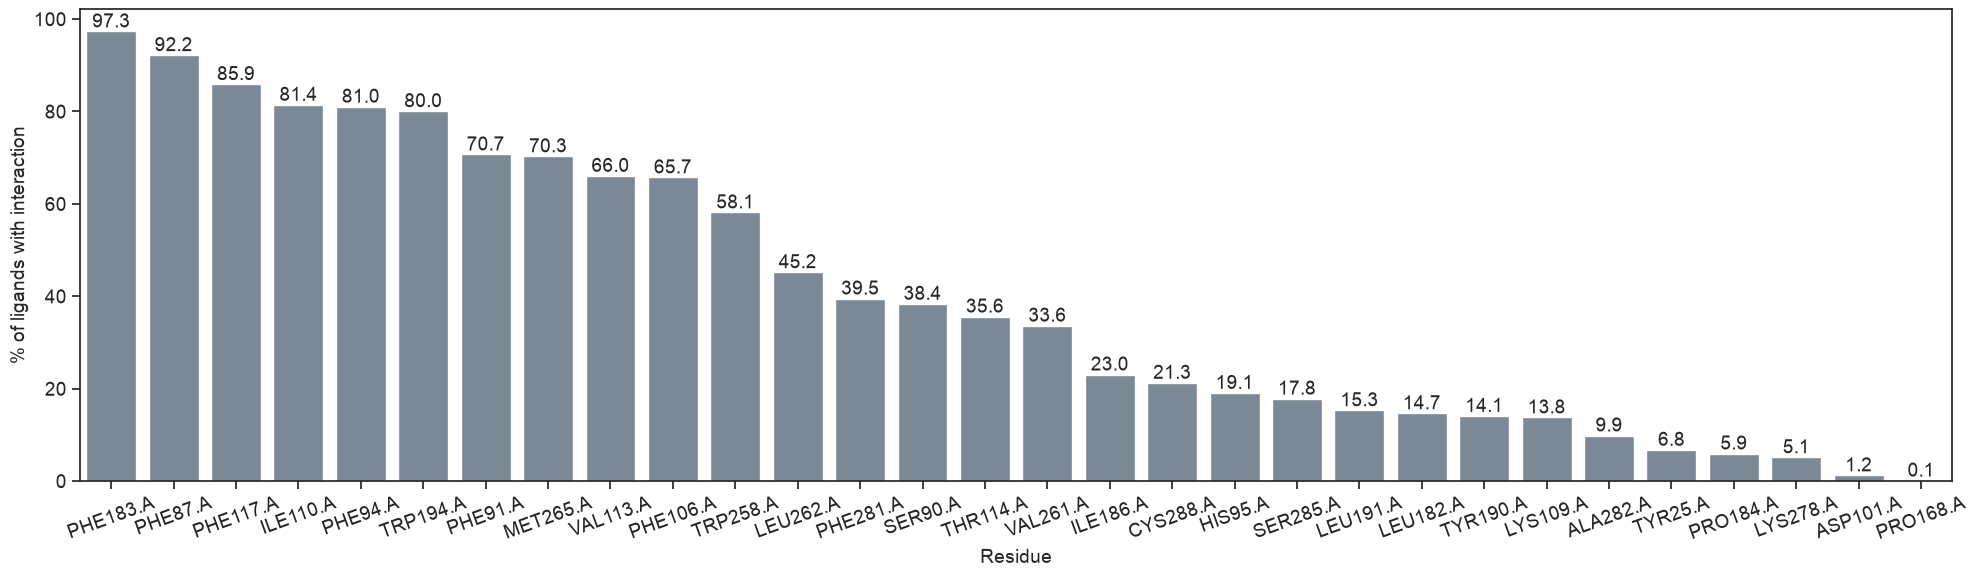

In [39]:
# 10 residues most frequently interacting with the ligand
residue_interactions_df = (
                            fp.to_dataframe().T.groupby(level=["ligand", "protein"])
                            .sum()
                            .T.astype(bool)
                            .mean()
                            .sort_values(ascending=False)
                            # .head(10)
                            .to_frame("%")
                            .T
                            * 100
                        )["UNL1"]
plt.figure(figsize=(20, 6))
g = sns.barplot(residue_interactions_df, color="lightslategray")
plt.xticks(rotation=20)
plt.ylabel("% of ligands with interaction")
plt.xlabel("Residue")
plt.bar_label(g.containers[0], fmt="%.1f", label_type="edge");

10 residues most frequently interacting with the ligand

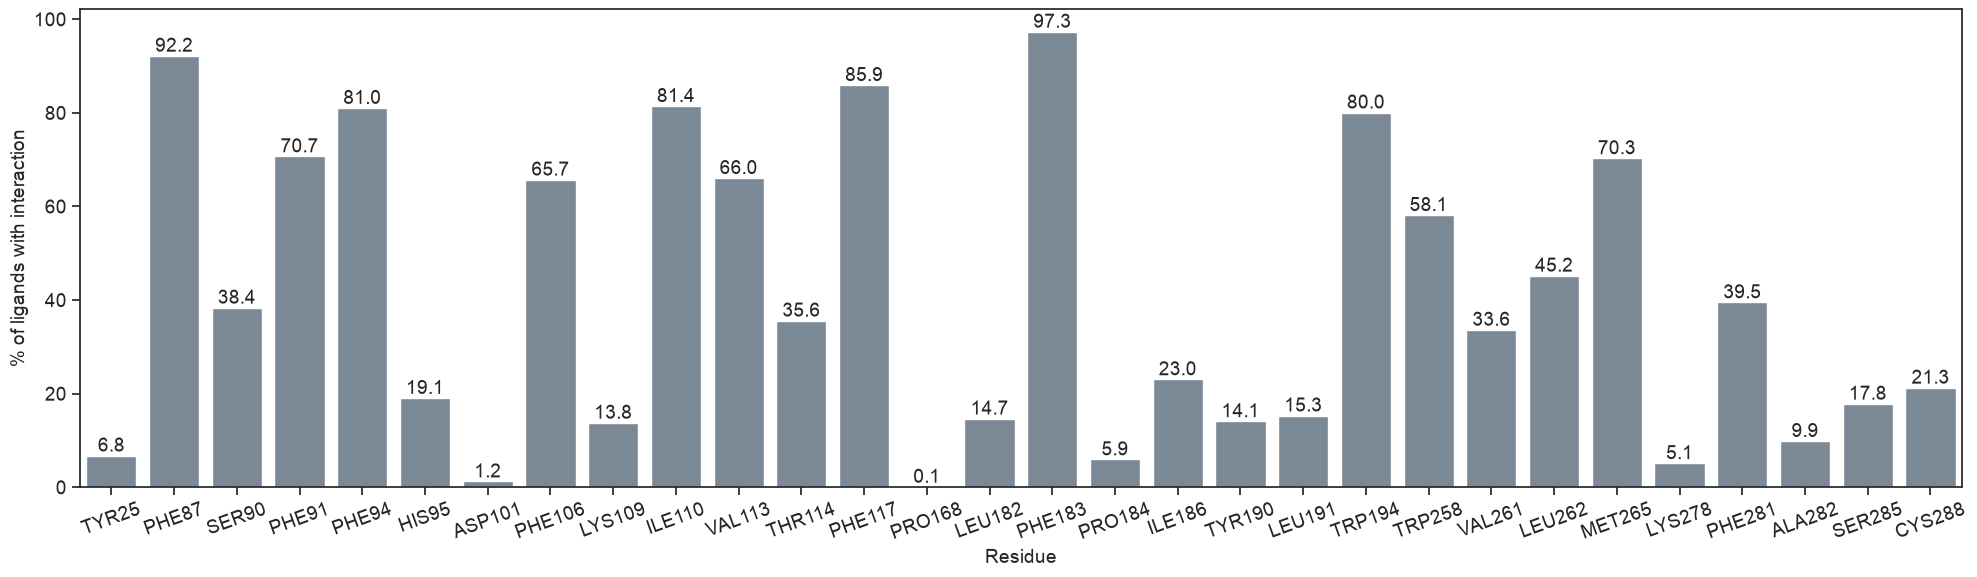

In [40]:
# 10 residues most frequently interacting with the ligand
residue_interactions_df = (
                            fp.to_dataframe().T.groupby(level=["ligand", "protein"])
                            .sum()
                            .T.astype(bool)
                            .mean()
                            .sort_values(ascending=False)
                            # .head(10)
                            .to_frame("%")
                            .T
                            * 100
                        )["UNL1"]
residue_interactions_df.columns = [col.replace(".A", "") for col in residue_interactions_df.columns]
three_letter_AA_code_pattern = r"(?<=[A-Z]{3})\w+" # grab the residue number after the 3-letter amino acid code
sorted_columns = sorted(residue_interactions_df.columns.to_list(), key=lambda x: int(re.findall(three_letter_AA_code_pattern, x)[0]))
residue_interactions_df = residue_interactions_df[sorted_columns] # reordering the columns based on the residue number
plt.figure(figsize=(20, 6))
g = sns.barplot(residue_interactions_df, color="lightslategray")
plt.xticks(rotation=20)
plt.ylabel("% of ligands with interaction")
plt.xlabel("Residue")
plt.bar_label(g.containers[0], fmt="%.1f", label_type="edge");

Percentage of poses where each interaction is present over all rounds

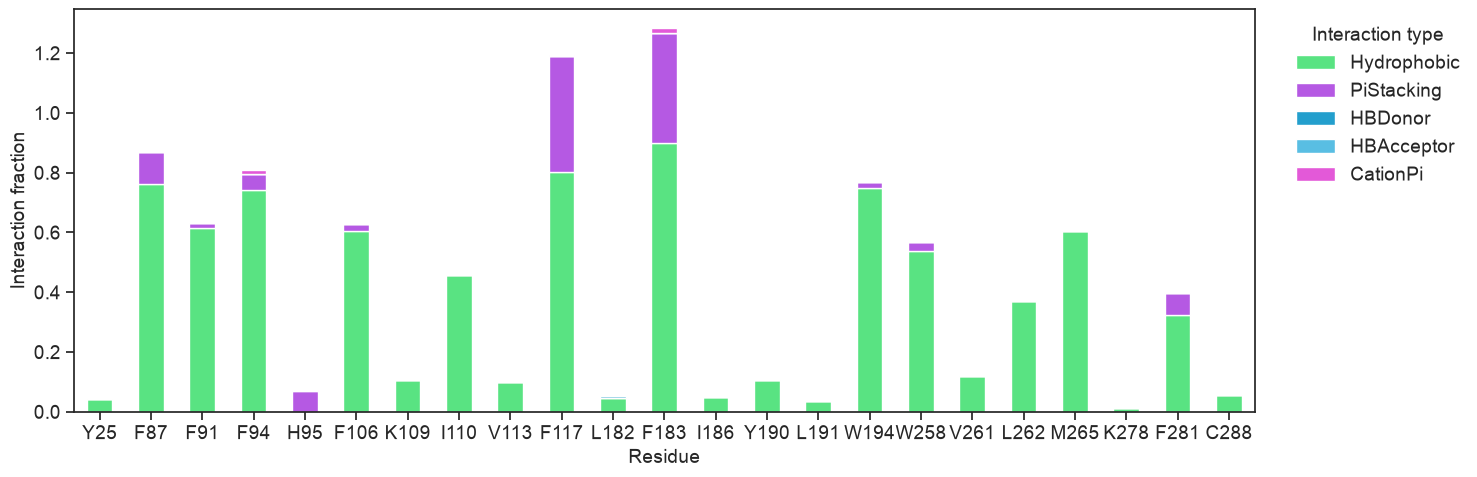

In [41]:
# percentage of poses where each interaction is present
interaction_percent_df = (fp.to_dataframe()
                                .mean()
                                .sort_values(ascending=False)
                                .to_frame(name="%").T).droplevel(level="ligand", axis=1)
long = interaction_percent_df.T.reset_index()
long.columns = ["protein", "interaction", "value"]  # value is fraction or % as in your screenshot

long = long.rename(columns={"value": "fraction"})

# 2) Pivot to wide: index = residue, columns = interaction type
plot_df = (
    long.pivot_table(
        index="protein",
        columns="interaction",
        values="fraction",
        aggfunc="sum",      # sum is fine; you have one row per (protein, interaction)
        fill_value=0.0,
    )
)

# some additional filtering to remove very low-frequency interactions (optional)
threshold = 0.01  # 1% of ligands
plot_df = plot_df.drop(columns=["VdWContact"])  # drop VdWContact as this very non-specific interaction dominates the plot
plot_df = plot_df[plot_df.sum(axis=1) > threshold] # drop residues with total interaction frequency below threshold


# Define a consistent palette per interaction type if you like
palette = {
    "Hydrophobic": "#59e382",
    "PiStacking": "#b559e3",
    "HBDonor": "#239fcd",
    "HBAcceptor": "#59bee3",
    "Cationic": "#e35959",
    "CationPi": "#e359d8",
    "SaltBridge": "#e377c2",
    "VdWContact": "#dfab43",
}

# Reorder the columns of plot_df to match the order of interaction types in the palette
sorted_interaction_types = [i for i in palette.keys() if i in plot_df.columns]
plot_df = plot_df[sorted_interaction_types]  # reorder columns to match palette order, which is defined roughly by interaction strength

# Sort the index (residues) based on the residue number extracted from the prolif residue names
sorted_residues = sort_prolif_resnames(plot_df.index.to_list())
plot_df = plot_df.loc[sorted_residues]  # reorder rows based on sorted

# Cleaning up the residue names for plotting
plot_df.index = plot_df.index.map(clean_prolif_resname)

figsize = (15, 5)
ax = (plot_df
        .plot(
            kind="bar",
            stacked=True,
            figsize=figsize,
            color=[palette.get(c, None) for c in plot_df.columns],
            rot=0,
    ))

ax.set_ylabel("Interaction fraction")  # or "% of poses with interaction"
ax.set_xlabel("Residue")

# If you’re working in 0–1 units:
# ax.set_xlim(0, 1.0)

ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left");

### Now plotting per round and per generation method

In [42]:
full_prolif_results_df = fp.to_dataframe()["UNL1"].copy()
full_prolif_results_df["smiles"] = gen_ligands_with_docking_poses_df["Smiles"].to_list()
full_prolif_results_df["method"] = gen_ligands_with_docking_poses_df["method"].to_list()
full_prolif_results_df["round"] = gen_ligands_with_docking_poses_df["round"].to_list()
full_prolif_results_df["docking_score"] = gen_ligands_with_docking_poses_df["docking_score"].to_list()

full_prolif_results_df

protein         TYR25.A                PHE87.A                       SER90.A  \
interaction Hydrophobic VdWContact Hydrophobic PiStacking VdWContact HBDonor   
Frame                                                                          
0                 False      False        True      False       True   False   
1                 False      False        True      False       True   False   
2                 False      False        True      False       True   False   
3                 False      False        True      False       True   False   
4                 False      False        True      False       True   False   
...                 ...        ...         ...        ...        ...     ...   
1223              False      False        True      False       True   False   
1224              False      False        True      False       True   False   
1225               True      False        True      False       True   False   
1226              False      False        True      False       True   False   
1227              False      False        True      False       True   False   

protein                    PHE91.A                        ...   PHE281.A  \
interaction VdWContact Hydrophobic PiStacking VdWContact  ... PiStacking   
Frame                                                     ...              
0                False        True      False       True  ...      False   
1                False        True      False       True  ...      False   
2                False        True      False       True  ...      False   
3                False        True      False      False  ...      False   
4                False        True      False       True  ...      False   
...                ...         ...        ...        ...  ...        ...   
1223             False        True      False       True  ...      False   
1224             False        True      False       True  ...      False   
1225              True        True      False       True  ...      False   
1226             False        True      False       True  ...      False   
1227             False        True      False      False  ...      False   

protein                  ALA282.A   SER285.A    CYS288.A             \
interaction VdWContact VdWContact VdWContact Hydrophobic VdWContact   
Frame                                                                 
0                False      False      False       False      False   
1                False      False      False       False      False   
2                False      False      False       False      False   
3                False      False      False       False      False   
4                False      False      False       False      False   
...                ...        ...        ...         ...        ...   
1223             False      False      False       False      False   
1224             False      False      False       False       True   
1225              True      False      False       False      False   
1226              True      False      False       False      False   
1227             False      False      False       False      False   

protein                                                 smiles    method  \
interaction                                                                
Frame                                                                      
0            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
1            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
2            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
3            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
4            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
...                                                        ...       ...   
1223         O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...  sampling   
1224         O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H

### Plotting interaction fractions per generation method and per round

In [43]:
# Assume df.columns.names == ["protein", "interaction"]
df = fp.to_dataframe().droplevel(level="ligand", axis=1)  # drop the ligand level, leaving only protein and interaction levels
residues = df.columns.get_level_values("protein").unique()

interaction_per_residue = {
    res: df[res].columns.tolist()    # columns under this residue are its interaction types
    for res in residues
}
print(interaction_per_residue)
# checking the residues that only have VdWContact interactions and no other interaction types
[res for res, interactions in interaction_per_residue.items() if (("VdWContact" in interactions) and (len(interactions) == 1))]


{'TYR25.A': ['Hydrophobic', 'VdWContact'], 'PHE87.A': ['Hydrophobic', 'PiStacking', 'VdWContact'], 'SER90.A': ['HBDonor', 'VdWContact'], 'PHE91.A': ['Hydrophobic', 'PiStacking', 'VdWContact'], 'PHE94.A': ['Hydrophobic', 'PiStacking', 'CationPi', 'VdWContact'], 'HIS95.A': ['HBDonor', 'PiStacking', 'VdWContact'], 'ASP101.A': ['HBDonor', 'VdWContact'], 'PHE106.A': ['Hydrophobic', 'PiStacking', 'VdWContact'], 'LYS109.A': ['Hydrophobic', 'HBDonor', 'HBAcceptor', 'VdWContact'], 'ILE110.A': ['Hydrophobic', 'VdWContact'], 'VAL113.A': ['Hydrophobic', 'VdWContact'], 'THR114.A': ['HBDonor', 'VdWContact'], 'PHE117.A': ['Hydrophobic', 'PiStacking', 'CationPi', 'VdWContact'], 'PRO168.A': ['VdWContact'], 'LEU182.A': ['Hydrophobic', 'HBDonor', 'VdWContact'], 'PHE183.A': ['Hydrophobic', 'PiStacking', 'CationPi', 'VdWContact'], 'PRO184.A': ['VdWContact'], 'ILE186.A': ['Hydrophobic', 'VdWContact'], 'TYR190.A': ['Hydrophobic', 'VdWContact'], 'LEU191.A': ['Hydrophobic', 'VdWContact'], 'TRP194.A': ['Hydroph

['PRO168.A', 'PRO184.A', 'ALA282.A', 'SER285.A']

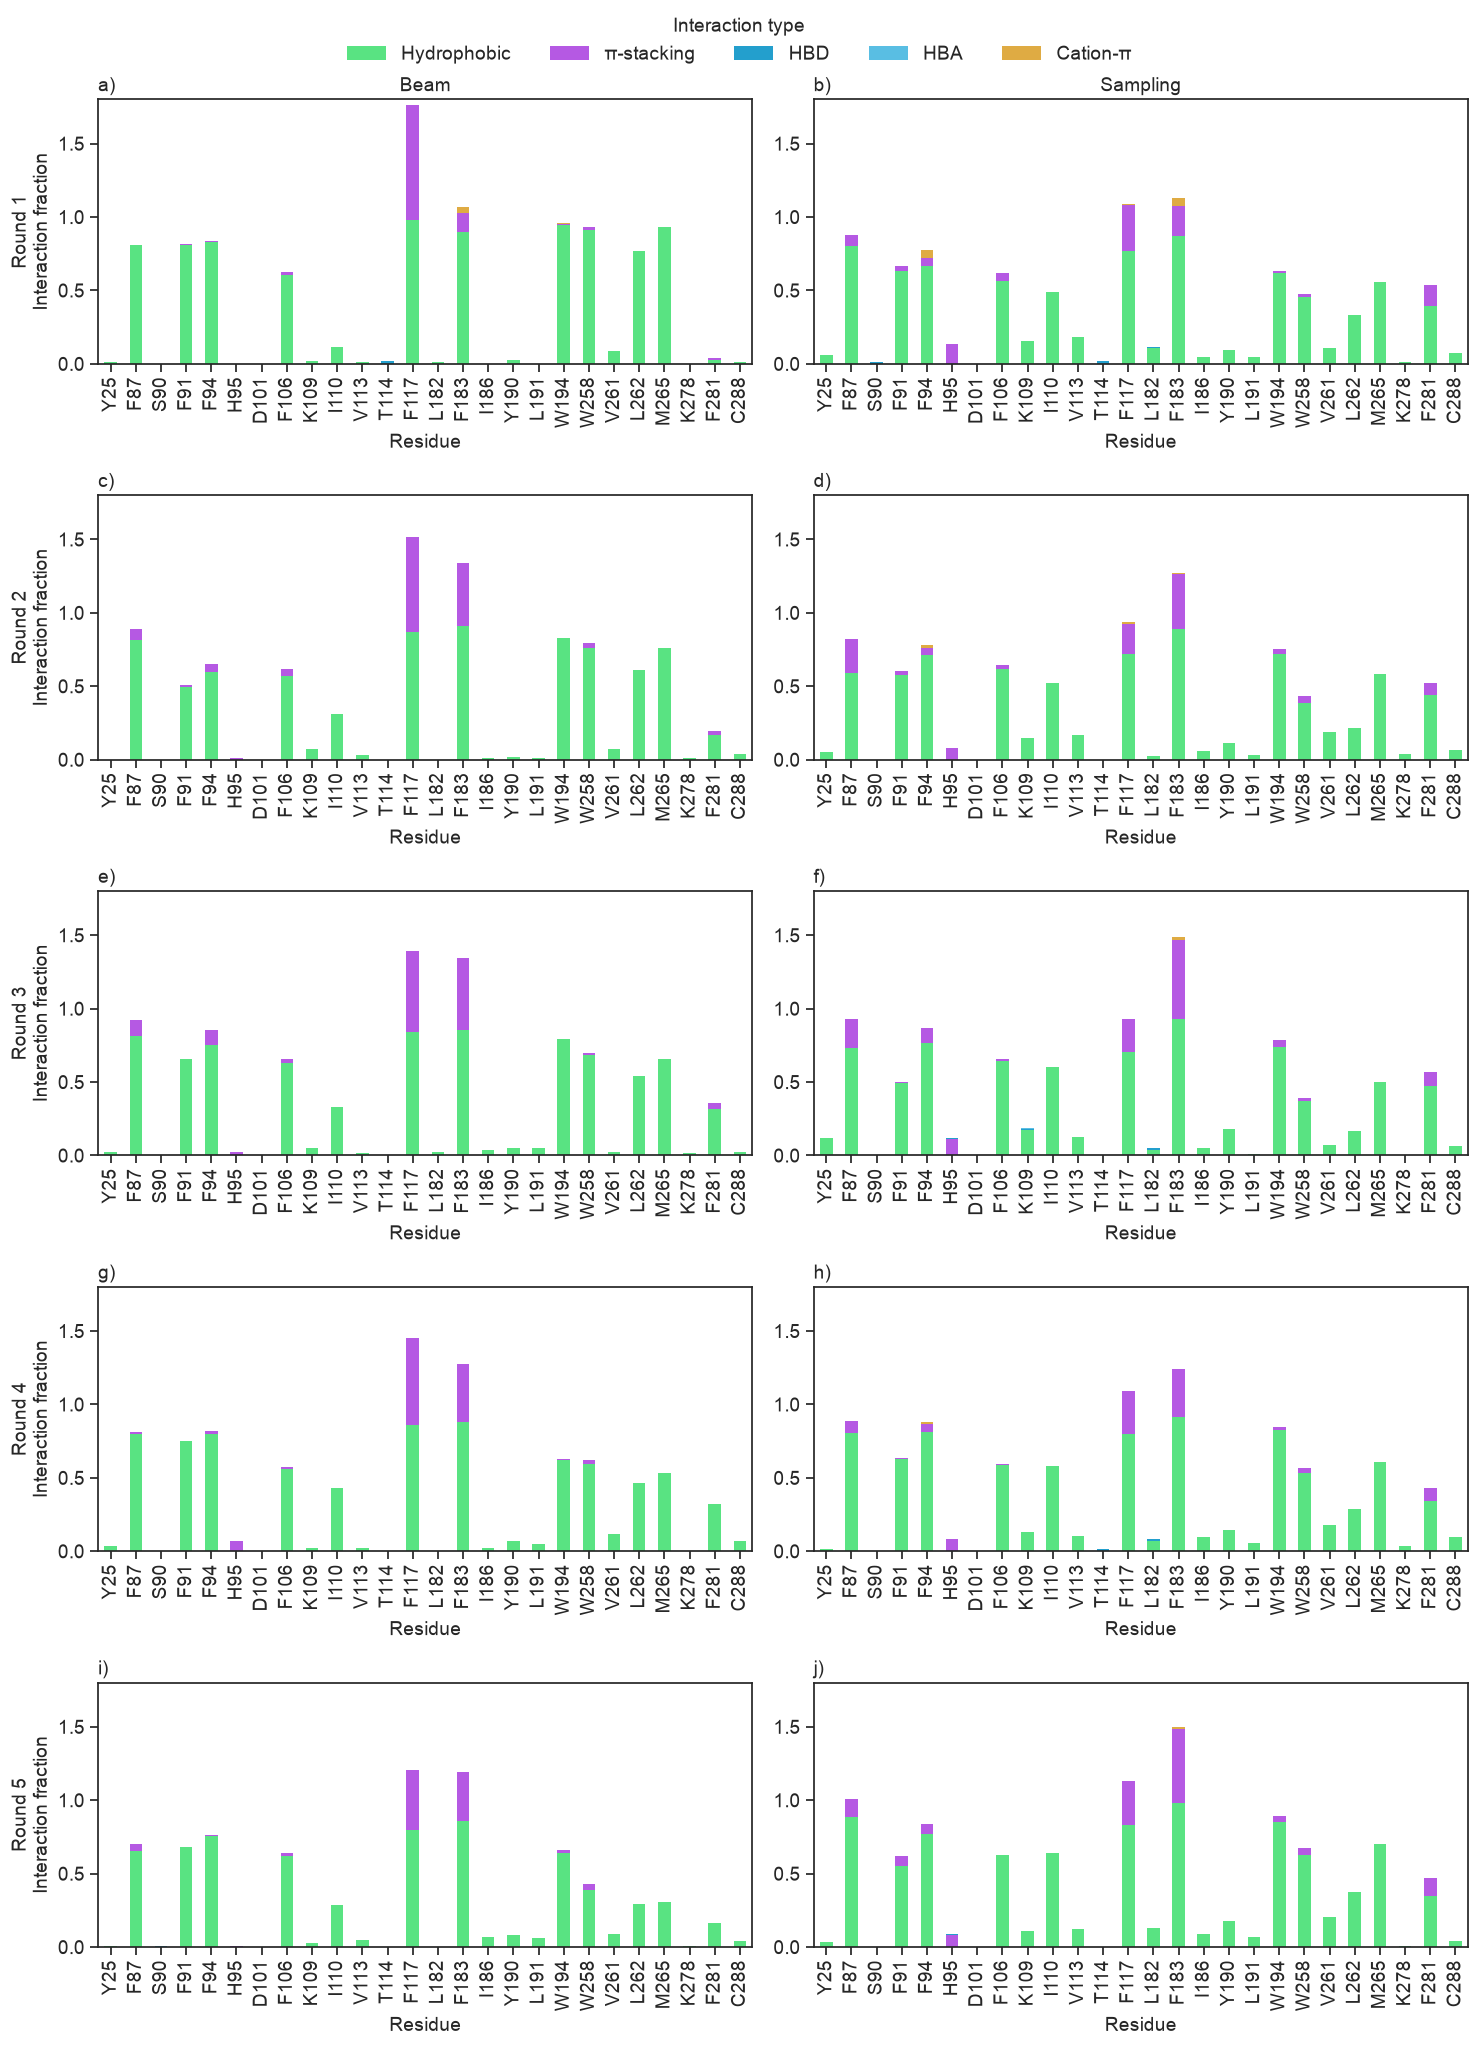

In [44]:
# Define a consistent palette per interaction type if you like
palette = {
    "Hydrophobic": "#59e382",
    "PiStacking": "#b559e3",
    "HBDonor": "#239fcd",
    "HBAcceptor": "#59bee3",
    "Cationic": "#e35959",
    "CationPi": "#dfab43",
    "SaltBridge": "#e377c2",
    "VdWContact": "#e359d8",
}

# Filtering residues to only those that have interactions other than VdWContact
df = fp.to_dataframe().droplevel(level="ligand", axis=1)  # drop the ligand level, leaving only protein and interaction levels
residues = df.columns.get_level_values("protein").unique()
interaction_per_residue = {
    res: df[res].columns.tolist()    # columns under this residue are its interaction types
    for res in residues
}
non_VdW_only_residues = [res for res, interactions in interaction_per_residue.items() if not (("VdWContact" in interactions) and (len(interactions) == 1))]
filtered_full_prolif_results_df = full_prolif_results_df[non_VdW_only_residues+["smiles", "method", "round", "docking_score"]]

# Setting up a grid of subplots for interaction fraction plots across methods and rounds
fig, axs = plt.subplots(5, 2, figsize=(15, 20))
methods = ["beam", "sampling"]
rounds = [f"round_{i}" for i in range(1, 5+1)] # note to self: this will need to be made generic for a final version of this code for the tool

# Loop through methods and rounds to create subplots
for i, method in enumerate(methods):
    for j, round_label in enumerate(rounds):
        ax = axs[j, i]
        subset_df = filtered_full_prolif_results_df[(filtered_full_prolif_results_df.method == method) & (filtered_full_prolif_results_df["round"] == round_label)]
        subset_df = subset_df.drop(columns=["smiles", "method", "round", "docking_score"], level=0) # need to specify level to avoid a PerformanceWarning
        subset_df = subset_df[subset_df.sum(axis=1) > 0] # drop ligands with no interactions
        
        # percentage of poses where each interaction is present
        interaction_percent_df = (subset_df
                                        .mean()
                                        .sort_values(ascending=False)
                                        .to_frame(name="%").T)#.droplevel(level="ligand", axis=1)
        long = interaction_percent_df.T.reset_index()
        long.columns = ["protein", "interaction", "value"]  # value is fraction or % as in your screenshot

        long = long.rename(columns={"value": "fraction"})

        # 2) Pivot to wide: index = residue, columns = interaction type
        plot_df = (
            long.pivot_table(
                index="protein",
                columns="interaction",
                values="fraction",
                aggfunc="sum",      # sum is fine; you have one row per (protein, interaction)
                fill_value=0.0,
            )
        )

        # some additional filtering to remove very low-frequency interactions (optional)
        # threshold = 0.01  # 1% of ligands
        plot_df = plot_df.drop(columns=["VdWContact"])  # drop VdWContact as this very non-specific interaction dominates the plot
        # plot_df = plot_df[plot_df.sum(axis=1) > threshold] # drop residues with total interaction frequency below threshold

        # Reorder the columns of plot_df to match the order of interaction types in the palette
        sorted_interaction_types = [i for i in palette.keys() if i in plot_df.columns]
        plot_df = plot_df[sorted_interaction_types]  # reorder columns to match palette order, which is defined roughly by interaction strength

        # Sort the index (residues) based on the residue number extracted from the prolif residue names
        sorted_residues = sort_prolif_resnames(plot_df.index.to_list())
        plot_df = plot_df.loc[sorted_residues]  # reorder rows based on sorted

        # Cleaning up the residue names for plotting
        plot_df.index = plot_df.index.map(clean_prolif_resname)

        # Plotting
        plot_df.plot(
                    kind="bar",
                    stacked=True,
                    color=[palette.get(c, None) for c in plot_df.columns],
                    rot=90,
                    ax=ax,
                    legend=False,
                    edgecolor="none"
                    )

        ax.set_ylabel("Interaction fraction")  # or "% of poses with interaction"
        ax.set_xlabel("Residue")

lines, labels = [ax.get_legend_handles_labels() for ax in fig.axes][0]
interaction_type_key_replacement = {"Hydrophobic": "Hydrophobic", "PiStacking": "π-stacking", "HBDonor": "HBD", "HBAcceptor": "HBA", "Cationic": "Cationic", "CationPi": "Cation-π", "SaltBridge": "Salt bridge", "VdWContact": "Van der Waals"}
labels = [interaction_type_key_replacement[label] for label in labels]
fig.legend(lines, labels, ncol=6, bbox_to_anchor=(0.5, 1.028), loc="upper center", title="Interaction type")

for ax in axs[:, 1]:
    ax.set_ylabel("")
for i, ax in enumerate(axs[:, 0], 1):
    ax.set_ylabel(f"Round {i}\nInteraction fraction")
axs[0,0].set_title("Beam")
axs[0,1].set_title("Sampling")

for ax in axs.flatten():
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.tick_params(axis='x', labelrotation=90)
    ax.minorticks_off()
    ax.set_ylim(0, 1.8)

label_figure_subplots(fig, axs=axs.flatten())

save_figure("interaction_fraction_by_residue_for_beam_and_sampling_by_round");

I think the main takeaway points here are the following:
- For both generation methods, as the rounds progress, the few hydrophilic interactions there are progressively decrease, indicating that molecules with nonpolar interactions have good docking scores and survive to the subsequent round. This is clearer for the multinomial sampling method inherently because it generates more 'divergent' structures, w.r.t. the starting point that can have more hydrophilic functional groups. For beam search, as the method only tends to generate small R-group changes, this point is less clear as fewer hydrophilic interacting groups are suggested (with the exception of a few compounds in round 1 of beam search forming cation-pi interactions).
- Multinomial sampling suggests compounds with an improved ability to pi-pi stack with the receptor compared to the beam search generated compounds, and this is likely the reason why multinomial sampling generated compounds tend to have lower (better) docking scores than beam search compounds. Not only do a higher proportion of compounds form pi-pi stacking interactions with the receptor from multinomial sampling, but considerably more residues are being interacted with in this way.

### Interaction fraction heatmap

Removing VdW contact information as it's primarily diagnostic and it drowns out all other types of interactions.

In [45]:
full_prolif_results_flat_columns_df = full_prolif_results_df.copy()
full_prolif_results_flat_columns_df.columns = [' '.join(col).strip() for col in full_prolif_results_df.columns.values]
full_prolif_results_flat_columns_df.index = full_prolif_results_flat_columns_df.index.rename("ligand")
columns_that_have_vdw_contact = [col for col in full_prolif_results_flat_columns_df.columns if 'VdWContact' in col]
prolif_results_no_vdw_df = full_prolif_results_flat_columns_df.drop(columns=columns_that_have_vdw_contact)
prolif_results_no_vdw_df.columns = [clean_prolif_resname(col) if " " in col else col for col in prolif_results_no_vdw_df.columns] # only the columns that have a space in them are prolif interaction columns, so we only want to clean those columns
# shortening intereaction names in the column names for better readability in plots and tables
interaction_name_short_map = {
    "Hydrophobic": "HP",
    "PiStacking": "π-stack",
    "HBDonor": "HBD",
    "HBAcceptor": "HBA",
    "CationPi": "Cation-π",
}

new_column_names = []
for col in prolif_results_no_vdw_df.columns:
    if " " in col: # if it's an interaction column, there wil be a space in the column name, otherwise it's a metadata column
        interaction_name = col.split(" ")[1]
        if interaction_name in interaction_name_short_map:
            new_col_name = col.replace(interaction_name, interaction_name_short_map[interaction_name])
            new_column_names.append(new_col_name)
    else:
        new_column_names.append(col)

prolif_results_no_vdw_df.columns = new_column_names
prolif_results_no_vdw_df["round"] = prolif_results_no_vdw_df["round"].replace("round_", "", regex=True)
prolif_results_no_vdw_df

,Y25 HP,F87 HP,F87 π-stack,S90 HBD,F91 HP,F91 π-stack,F94 HP,F94 π-stack,F94 Cation-π,H95 HBD,...,L262 HP,M265 HP,K278 HP,F281 HP,F281 π-stack,C288 HP,smiles,method,round,docking_score
ligand,,,,,,,,,,,,,,,,,,,,,
0,False,True,False,False,True,False,True,False,False,False,...,True,True,False,False,False,False,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,beam,1,-11.473
1,False,True,False,False,True,False,True,False,False,False,...,True,True,False,False,False,False,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,beam,1,-10.800
2,False,True,False,False,True,False,True,False,False,False,...,True,True,False,False,False,False,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,beam,1,-10.885
3,False,True,False,False,True,False,True,False,False,False,...,True,True,False,False,False,False,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,beam,1,-10.679
4,False,True,False,False,True,False,True,False,False,False,...,True,True,False,False,False,False,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...,beam,1,-10.829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,False,True,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...,sampling,5,-9.513
1224,False,True,False,False,True,False,False,False,False,False,...,True,True,False,True,False,False,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H...,sampling,5,-10.995
1225,True,True,False,False,True,False,True,False,False,False,...,False,True,False,True,False,False,COc1ccc(C[C@H]2C[C@H](C(=O)N[C@]34C[C@H]5C[C@H...,sampling,5,-12.439


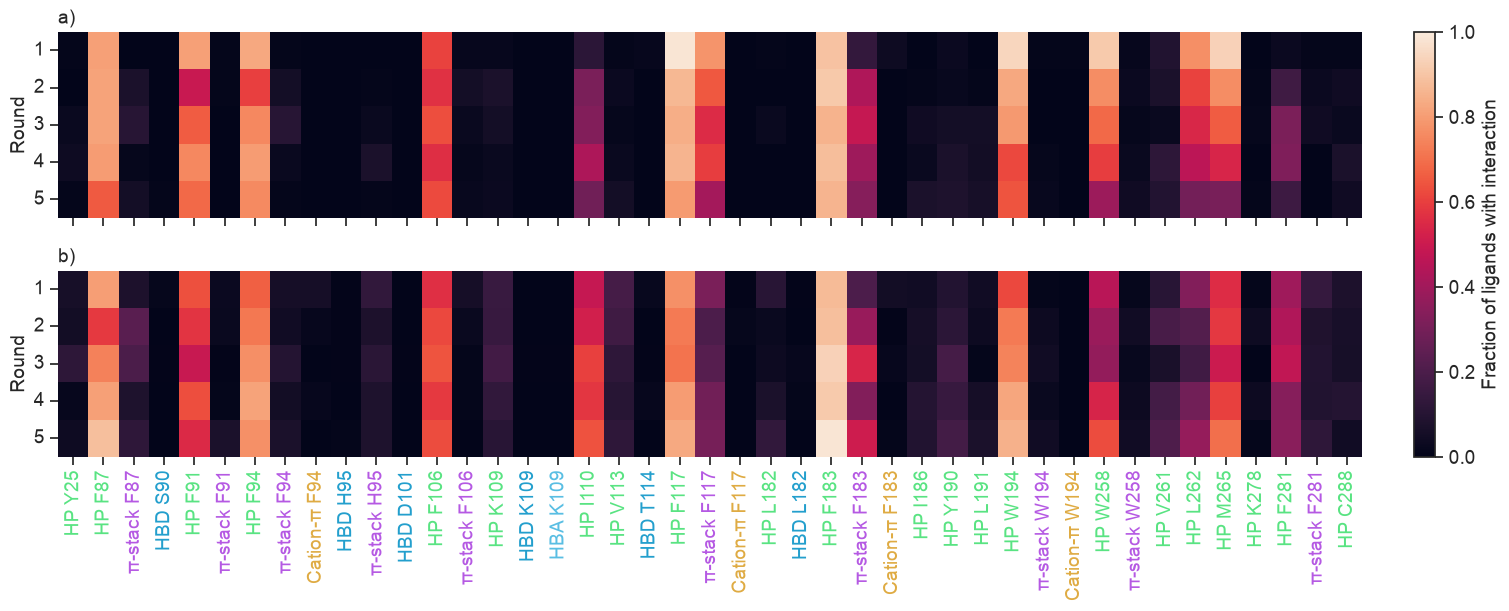

In [46]:
interaction_fraction_matrix_df = prolif_results_no_vdw_df.drop(columns=["smiles", "docking_score"]).groupby(["method", "round"]).mean()
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=True, constrained_layout=True)
axs = axs.flatten()

sns.heatmap(interaction_fraction_matrix_df.loc["beam"], ax=axs[0], vmin=0, vmax=1, cbar=False)
axs[0].set_ylabel("Round")
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0)
sns.heatmap(interaction_fraction_matrix_df.loc["sampling"], ax=axs[1], vmin=0, vmax=1, cbar=False)
axs[1].set_ylabel("Round")
axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0)
cbar = fig.colorbar(
    axs[0].collections[0],
    ax=axs,          # attach to both subplots
    location="right",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Fraction of ligands with interaction")
fig.get_layout_engine().set(hspace=0.1)
label_figure_subplots(fig, axs=axs)

# change tick label colour
interaction_type_colours = {
    "HP": "#59e382",
    "π-stack": "#b559e3",
    "HBD": "#239fcd",
    "HBA": "#59bee3",
    "Cation-π": "#dfab43",
}
label_colours = {label: interaction_type_colours[label.get_text().split(" ")[-1]] for label in axs[1].get_xticklabels() if label.get_text().split(" ")[-1] in interaction_type_colours}
# Apply colors from the dict
for lbl in axs[1].get_xticklabels():
    text = lbl.get_text()
    if lbl in label_colours:
        lbl.set_color(label_colours[lbl])

# flipping the x-axis labels to have interaction type first, then the residue for better readability
new_labels = []
for label in axs[1].get_xticklabels():
    text = label.get_text()
    if " " in text:
        residue, interaction_type = text.split(" ")
        new_label = f"{interaction_type} {residue}"
        new_labels.append(new_label)
    else:
        new_labels.append(text)
axs[1].set_xticklabels(new_labels, rotation=90)

save_figure("interaction_fraction_heatmap_by_method_and_round");

## Looking into the best scoring molecules per round per generation method

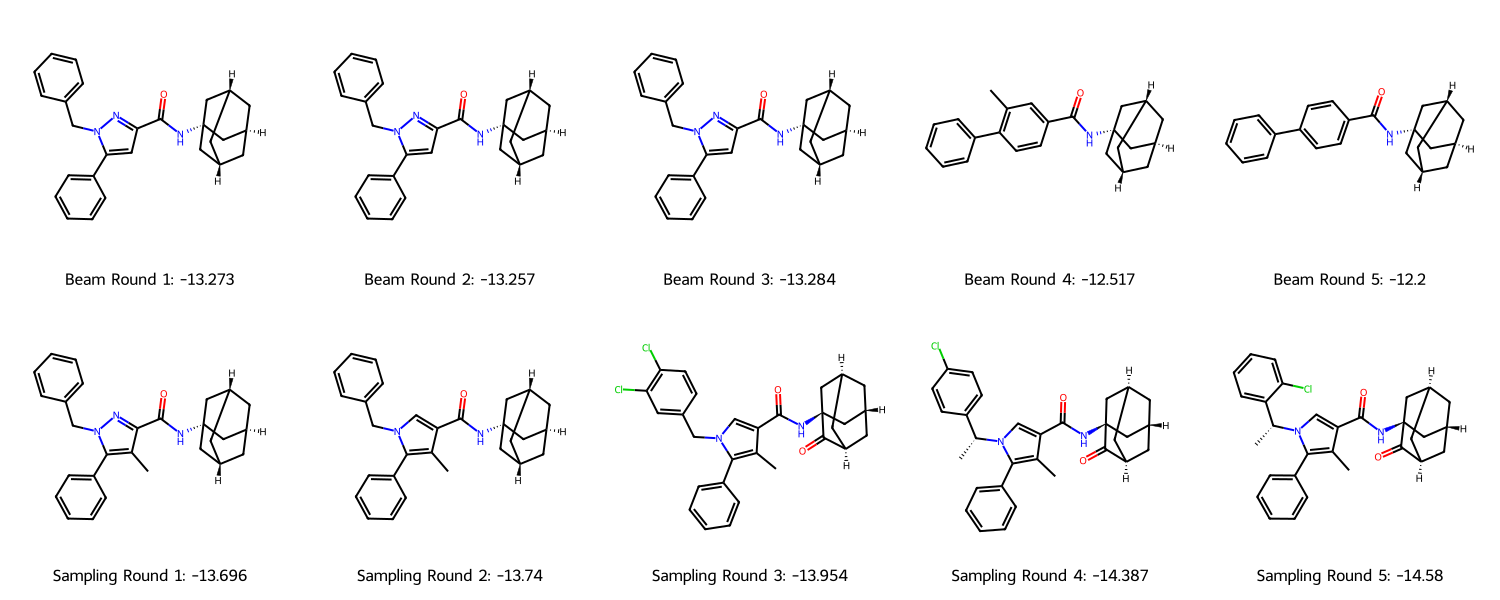

In [47]:
best_scoring_molecules_per_round_idxs = full_prolif_results_df.groupby(by=["method", "round"])["docking_score"].idxmin().values
best_scoring_molecules_per_round_df = full_prolif_results_df.iloc[best_scoring_molecules_per_round_idxs]
best_scoring_molecules_per_round_df
best_smiles_beam_and_sampling = best_scoring_molecules_per_round_df.smiles.to_list()
best_scores_beam_and_sampling = best_scoring_molecules_per_round_df.docking_score.to_list()
legends = [f"Beam Round {i+1}: {score}" for i, score in enumerate(best_scores_beam_and_sampling[:5])] + [f"Sampling Round {i+1}: {score}" for i, score in enumerate(best_scores_beam_and_sampling[5:])]
Draw.MolsToGridImage([Chem.MolFromSmiles(smiles) for smiles in best_smiles_beam_and_sampling], molsPerRow=5, subImgSize=(300, 300), legends=legends)

It is clear that there is a duplication problem due to not tracking what molecules have already been generated across an entire run. Beam search suffers greatly from this issue having generated the same molecule for three rounds, and then it seems to have suffered from some sort of collapse where a different molecule has been generated, but this molecule has a significantly worse docking score.

## Counting duplicates per generation method

In [48]:
full_count_per_gen_method_dict = full_prolif_results_df.groupby("method").size().to_dict()
full_count_per_gen_method_dict

{'beam': 459, 'sampling': 769}

In [49]:
duplicates_per_gen_method_dict = full_prolif_results_df.groupby("method")["smiles"].apply(lambda x: x.duplicated().sum()).to_dict()
duplicates_per_gen_method_dict

{'beam': 114, 'sampling': 10}

In [50]:
print(f"Beam search duplicate percentage: {(duplicates_per_gen_method_dict['beam']/full_count_per_gen_method_dict['beam'])*100:.2f}%")
print(f"Multinomial sampling duplicate percentage: {(duplicates_per_gen_method_dict['sampling']/full_count_per_gen_method_dict['sampling'])*100:.2f}%")

Beam search duplicate percentage: 24.84%
Multinomial sampling duplicate percentage: 1.30%


In [51]:
smiles_per_method_and_round_df = full_prolif_results_df.copy().reset_index(drop=True)[["smiles", "method", "round"]]
# smiles are canonicalized just in case, but they should be already as part of ligand prep
smiles_per_method_and_round_df = pd.DataFrame({"smiles": smiles_per_method_and_round_df["smiles"].apply(Chem.CanonSmiles), "method": smiles_per_method_and_round_df["method"], "round": smiles_per_method_and_round_df["round"]})
beam_smiles = []
beam_duplicate_count_dict = {}
beam_total_count_dict = {}
sampling_smiles = []
sampling_duplicate_count_dict = {}
sampling_total_count_dict = {}
rounds_list = sorted(smiles_per_method_and_round_df["round"].unique())
for round_label in rounds_list:
    # beam duplicates
    beam_smiles.extend(smiles_per_method_and_round_df.query(f"method == 'beam' and round == '{round_label}'")["smiles"].to_list())
    beam_duplicate_count = pd.Series(beam_smiles).duplicated().sum()
    beam_duplicate_count_dict[round_label] = beam_duplicate_count
    beam_total_count_dict[round_label] = len(beam_smiles)
    # sampling duplicates
    sampling_smiles.extend(smiles_per_method_and_round_df.query(f"method == 'sampling' and round == '{round_label}'")["smiles"].to_list())
    sampling_duplicate_count = pd.Series(sampling_smiles).duplicated().sum()
    sampling_duplicate_count_dict[round_label] = sampling_duplicate_count
    sampling_total_count_dict[round_label] = len(sampling_smiles)

print("Beam")
print(beam_duplicate_count_dict)
print(beam_total_count_dict)
print()
print("Sampling")
print(sampling_duplicate_count_dict)
print(sampling_total_count_dict)

Beam
{'round_1': np.int64(0), 'round_2': np.int64(20), 'round_3': np.int64(47), 'round_4': np.int64(79), 'round_5': np.int64(114)}
{'round_1': 104, 'round_2': 201, 'round_3': 277, 'round_4': 361, 'round_5': 459}

Sampling
{'round_1': np.int64(0), 'round_2': np.int64(1), 'round_3': np.int64(1), 'round_4': np.int64(4), 'round_5': np.int64(10)}
{'round_1': 197, 'round_2': 355, 'round_3': 532, 'round_4': 656, 'round_5': 769}


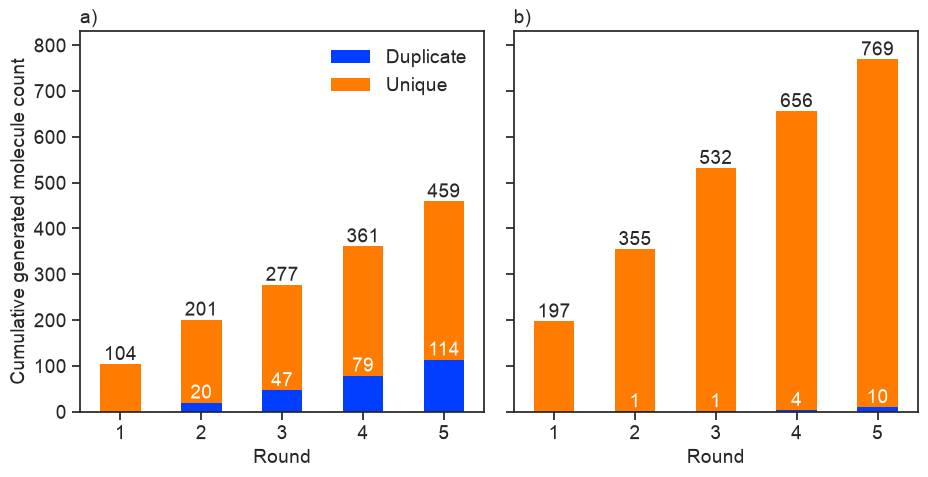

In [52]:
# beam
beam_duplicate_df = pd.DataFrame.from_dict(beam_duplicate_count_dict, orient='index', columns=['duplicate'])
beam_duplicate_df["total"] = pd.Series(beam_total_count_dict)
beam_duplicate_df["unique"] = beam_duplicate_df["total"] - beam_duplicate_df["duplicate"]
beam_duplicate_df["method"] = "beam"
beam_duplicate_df = beam_duplicate_df.reset_index(names="round")
# sampling
sampling_duplicate_df = pd.DataFrame.from_dict(sampling_duplicate_count_dict, orient='index', columns=['duplicate'])
sampling_duplicate_df["total"] = pd.Series(sampling_total_count_dict)
sampling_duplicate_df["unique"] = sampling_duplicate_df["total"] - sampling_duplicate_df["duplicate"]
sampling_duplicate_df["method"] = "sampling"
sampling_duplicate_df = sampling_duplicate_df.reset_index(names="round")

beam_and_sampling_duplicate_df = pd.concat([beam_duplicate_df, sampling_duplicate_df], ignore_index=True)
beam_and_sampling_duplicate_df["round"] = beam_and_sampling_duplicate_df["round"].replace("round_", "", regex=True)
beam_and_sampling_duplicate_df.columns = beam_and_sampling_duplicate_df.columns.str.capitalize()

fig, axs = plt.subplots(1, 2, figsize=(9.5, 5), sharey=True)
# axs = axs.flat
beam_and_sampling_duplicate_df.query("Method == 'beam'").plot(x="Round", y=["Duplicate", "Unique"], kind="bar", stacked=True, rot=0, ylabel="Cumulative generated molecule count", ax=axs[0], edgecolor="none");
beam_and_sampling_duplicate_df.query("Method == 'sampling'").plot(x="Round", y=["Duplicate", "Unique"], kind="bar", stacked=True, rot=0, ylabel="Cumulative generated molecule count", ax=axs[1], edgecolor="none");
axs[1].legend_.remove()
axs[0].bar_label(axs[0].containers[0], label_type="edge", color="w", labels=[f"{int(label)}" if i!=0 else "" for i, label in enumerate(axs[0].containers[0].datavalues)])
axs[1].bar_label(axs[1].containers[0], label_type="edge", color="w", labels=[f"{int(label)}" if i!=0 else "" for i, label in enumerate(axs[1].containers[0].datavalues)])
axs[0].bar_label(axs[0].containers[1], label_type="edge", labels=beam_and_sampling_duplicate_df.query("Method == 'beam'")["Total"].astype(int).tolist())
axs[1].bar_label(axs[1].containers[1], label_type="edge", labels=beam_and_sampling_duplicate_df.query("Method == 'sampling'")["Total"].astype(int).tolist())
plt.ylim(0, 830)
label_figure_subplots(fig, axs=axs)
save_figure("cumulative_total_and_duplicate_molecule_count_by_method_and_round");

### Checking why there are duplicates despite deduplication checkpoints

In [53]:
input_beam_mols = pd.read_csv("results/workflow/beam/docking_score/round_3/annalog_generated_molecules.tsv", sep="\t")["input_smiles"]
input_beam_mols_canon = input_beam_mols.apply(lambda x: Chem.CanonSmiles(x))
generated_beam_mols = pd.read_csv("results/workflow/beam/docking_score/round_3/ligand_prep/prepped_ligands.csv")["annalog"]
generated_beam_mols_canon = generated_beam_mols.apply(lambda x: Chem.CanonSmiles(x))

set(input_beam_mols_canon.to_list()) & set(generated_beam_mols_canon.to_list())

set()

The above code verifies that the generated molecules are correctly being removed if they are the same as an input molecule. This means that for beam search to keep generating the same molecule and docking it, the molecule is regenerated during the ligand prepration process.

In [54]:
beam_search_problematic_gen_mol_df = pd.read_csv("results/workflow/beam/docking_score/round_3/ligand_prep/prepped_ligands.csv")
beam_search_problematic_gen_mol_df["annalog"] = beam_search_problematic_gen_mol_df["annalog"].apply(lambda x: Chem.CanonSmiles(x))
beam_search_problematic_gen_mol_df["protonated"] = beam_search_problematic_gen_mol_df["protonated"].apply(lambda x: Chem.CanonSmiles(x))
beam_search_problematic_gen_mol_df["isomers"] = beam_search_problematic_gen_mol_df["isomers"].apply(lambda x: Chem.CanonSmiles(x))
beam_duplicated_problematic_smiles = Chem.CanonSmiles(best_smiles_beam_and_sampling[2])
matching_problematic_entry = beam_search_problematic_gen_mol_df.apply(lambda row: row[row==beam_duplicated_problematic_smiles], axis=1).dropna()
matching_problematic_index = matching_problematic_entry.index.to_list()[0]
matching_problematic_entry

,isomers
14,O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)c1cc(...


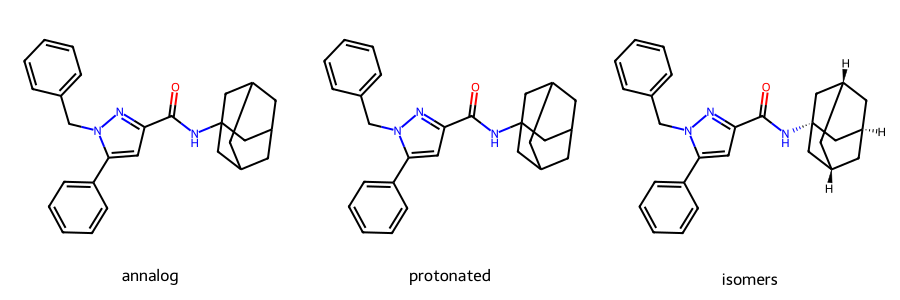

In [55]:
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in beam_search_problematic_gen_mol_df.iloc[matching_problematic_index].to_list()[1:]], legends=["annalog", "protonated", "isomers"], subImgSize=(300, 300))

Since the initial ANNalog generated molecule has no defined stereochemistry (as it shouldn't as it has no stereocentres), the initial deduplication does not catch this generated molecule as the input molecule has defined stereochemistry (see the third molecule directly above). This is how beam search is able to keep regenerating the same molecule without being affected by the two deduplication checkpoints. I have also confirmed that this exact thing happened for all three initial rounds of the beam search run where the best scoring molecule was the same molecule back-to-back-to-back.

## Plotting generated molecules with UMAP and highlighting docking score

In [56]:
binding_pose_mapper = umap.UMAP(random_state=42).fit(np.array(fp.to_bitvectors()))
umap_binding_pose_fp_df = pd.DataFrame(binding_pose_mapper.embedding_, columns=["UMAP1", "UMAP2"])
umap_binding_pose_fp_df["method"] = full_prolif_results_df["method"].to_list()
umap_binding_pose_fp_df["round"] = full_prolif_results_df["round"].to_list()
umap_binding_pose_fp_df["docking_score"] = full_prolif_results_df["docking_score"].to_list()
umap_binding_pose_fp_df["smiles"] = full_prolif_results_df["smiles"].to_list()
umap_binding_pose_fp_df_ds_filtered = umap_binding_pose_fp_df.copy().query("docking_score <= -5.0")

/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


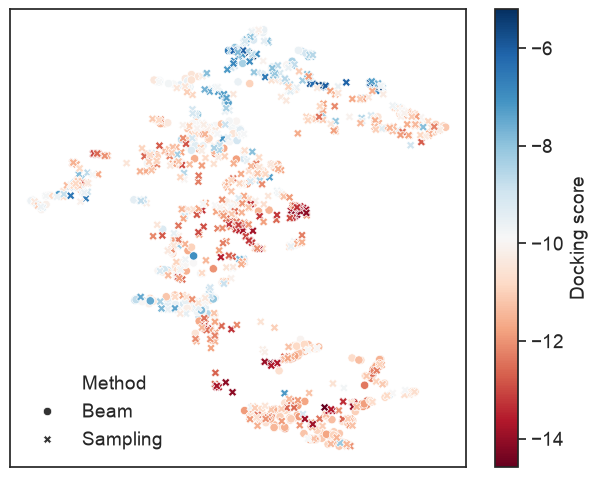

In [57]:
plt.figure(figsize=(6.2,5))
palette = "RdBu"
ax = sns.scatterplot(data=umap_binding_pose_fp_df_ds_filtered, x="UMAP1", y="UMAP2", hue="docking_score", style="method", palette=palette)
norm = plt.Normalize(umap_binding_pose_fp_df_ds_filtered['docking_score'].min(), umap_binding_pose_fp_df_ds_filtered['docking_score'].max())
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
# ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
handles = handles[-3:] # only grab the last 3 handles (the ones corresponding to the methods)
labels = labels[-3:] # only grab the last 3 labels (the ones corresponding to the methods)
labels = [label.title() for label in labels] # capitalize the first letter of each label
ax.legend(handles, labels)
cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("Docking score")

# removing ticks and labels
ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
plt.ylabel("")
plt.xlabel("")
save_figure("umap_projection_of_binding_pose_fingerprints_colored_by_docking_score");

## Getting best binding poses

### Adding cognate to prolif analysis

In [58]:
cognate_ligand_row = known_generated_and_cognate_ligands_df.query("method == 'cognate'").copy()
cognate_ligand_docking_pose_path = "redocking/5ZTY_inactive/structures/ligand/9JU_corrected_pose.sdf"
cognate_ligand_row["docking_pose_path"] = cognate_ligand_docking_pose_path
cognate_ligand_row["docking_score"] = cognate_ligand.docking_score
cognate_and_gen_ligands_with_docking_poses_df = pd.concat([cognate_ligand_row, gen_ligands_with_docking_poses_df])

In [59]:
ligands_with_cognate_plf = [plf.sdf_supplier(filepath) for filepath in cognate_and_gen_ligands_with_docking_poses_df["docking_pose_path"].unique()] # loading docked structures into prolif
ligands_with_cognate = list(chain.from_iterable(ligands_with_cognate_plf)) # flattening the list of lists into a single list of ligands
fp_with_cognate = plf.Fingerprint()
fp_with_cognate.run_from_iterable(ligands_with_cognate, protein_plf)

  0%|          | 0/1229 [00:00<?, ?it/s]

<prolif.fingerprint.Fingerprint: 9 interactions: ['Hydrophobic', 'HBDonor', 'HBAcceptor', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact'] at 0x36ed6e990>

In [60]:
full_prolif_results_with_cognate_df = fp_with_cognate.to_dataframe()["UNL1"].copy()
full_prolif_results_with_cognate_df["smiles"] = cognate_and_gen_ligands_with_docking_poses_df["Smiles"].to_list()
full_prolif_results_with_cognate_df["method"] = cognate_and_gen_ligands_with_docking_poses_df["method"].to_list()
full_prolif_results_with_cognate_df["round"] = cognate_and_gen_ligands_with_docking_poses_df["round"].to_list()
full_prolif_results_with_cognate_df["docking_score"] = cognate_and_gen_ligands_with_docking_poses_df["docking_score"].to_list()

full_prolif_results_with_cognate_df

protein         TYR25.A                PHE87.A                       SER90.A  \
interaction Hydrophobic VdWContact Hydrophobic PiStacking VdWContact HBDonor   
Frame                                                                          
0                 False      False        True      False       True   False   
1                 False      False        True      False       True   False   
2                 False      False        True      False       True   False   
3                 False      False        True      False       True   False   
4                 False      False        True      False       True   False   
...                 ...        ...         ...        ...        ...     ...   
1224              False      False        True      False       True   False   
1225              False      False        True      False       True   False   
1226               True      False        True      False       True   False   
1227              False      False        True      False       True   False   
1228              False      False        True      False       True   False   

protein                    PHE91.A                        ...   PHE281.A  \
interaction VdWContact Hydrophobic PiStacking VdWContact  ... PiStacking   
Frame                                                     ...              
0                False        True      False       True  ...      False   
1                False        True      False       True  ...      False   
2                False        True      False       True  ...      False   
3                False        True      False       True  ...      False   
4                False        True      False      False  ...      False   
...                ...         ...        ...        ...  ...        ...   
1224             False        True      False       True  ...      False   
1225             False        True      False       True  ...      False   
1226              True        True      False       True  ...      False   
1227             False        True      False       True  ...      False   
1228             False        True      False      False  ...      False   

protein                  ALA282.A   SER285.A    CYS288.A             \
interaction VdWContact VdWContact VdWContact Hydrophobic VdWContact   
Frame                                                                 
0                False      False      False       False      False   
1                False      False      False       False      False   
2                False      False      False       False      False   
3                False      False      False       False      False   
4                False      False      False       False      False   
...                ...        ...        ...         ...        ...   
1224             False      False      False       False      False   
1225             False      False      False       False       True   
1226              True      False      False       False      False   
1227              True      False      False       False      False   
1228             False      False      False       False      False   

protein                                                 smiles    method  \
interaction                                                                
Frame                                                                      
0            Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...   cognate   
1            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
2            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
3            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
4            Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...      beam   
...                                                        ...       ...   
1224         O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@H]...  sampling   
1225         O=C(N[C@]12C[C@H]3C[C@H](C[C@H](C3)C1)C2)[C@@H

In [61]:
binding_pose_with_cognate_mapper = umap.UMAP(random_state=42).fit(np.array(fp_with_cognate.to_bitvectors()))
umap_binding_pose_with_cognate_fp_df = pd.DataFrame(binding_pose_with_cognate_mapper.embedding_, columns=["UMAP1", "UMAP2"])
umap_binding_pose_with_cognate_fp_df["method"] = full_prolif_results_with_cognate_df["method"].to_list()
umap_binding_pose_with_cognate_fp_df["round"] = full_prolif_results_with_cognate_df["round"].to_list()
umap_binding_pose_with_cognate_fp_df["docking_score"] = full_prolif_results_with_cognate_df["docking_score"].to_list()
umap_binding_pose_with_cognate_fp_df["smiles"] = full_prolif_results_with_cognate_df["smiles"].to_list()
umap_binding_pose_with_cognate_fp_df_ds_filtered = umap_binding_pose_with_cognate_fp_df.copy().query("docking_score <= -5.0")

/Users/dcriveanu/miniconda3/envs/statistical_molecule_plotting/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


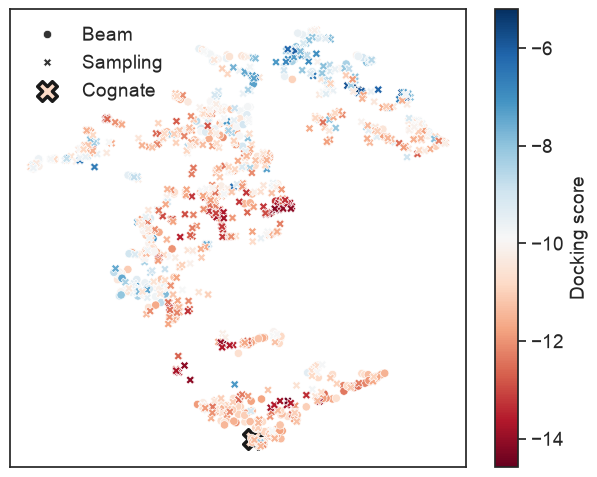

In [62]:
plt.figure(figsize=(6.2,5))
palette = "RdBu"
umap_binding_pose_with_cognate_fp_df_ds_filtered_not_cognate = umap_binding_pose_with_cognate_fp_df_ds_filtered.query("method != 'cognate'")
umap_binding_pose_with_cognate_fp_df_ds_filtered_only_cognate = umap_binding_pose_with_cognate_fp_df_ds_filtered.query("method == 'cognate'")
ax = sns.scatterplot(data=umap_binding_pose_with_cognate_fp_df_ds_filtered_not_cognate, x="UMAP1", y="UMAP2", hue="docking_score", style="method", palette=palette)
norm = plt.Normalize(umap_binding_pose_with_cognate_fp_df_ds_filtered['docking_score'].min(), umap_binding_pose_with_cognate_fp_df_ds_filtered['docking_score'].max())
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])

palette_cmap = plt.get_cmap(palette)
cognate_color = palette_cmap(norm(umap_binding_pose_with_cognate_fp_df_ds_filtered_only_cognate["docking_score"].iloc[0]))
ax.scatter(
    umap_binding_pose_with_cognate_fp_df_ds_filtered_only_cognate["UMAP1"],
    umap_binding_pose_with_cognate_fp_df_ds_filtered_only_cognate["UMAP2"],
    s=200,
    marker="X",
    color=cognate_color,
    linewidths=2.5,
    zorder=-10,
    edgecolor="k",
    label="Cognate"
)

# Remove the legend and add a colorbar
# ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
handles = handles[-3:] # only grab the last 3 handles (the ones corresponding to the methods)
labels = labels[-3:] # only grab the last 3 labels (the ones corresponding to the methods)
labels = [label.title() for label in labels] # capitalize the first letter of each label
ax.legend(handles, labels)
cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("Docking score")

# removing ticks and labels
ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
plt.ylabel("")
plt.xlabel("")
save_figure("umap_projection_of_binding_pose_fingerprints_colored_by_docking_score_with_cognate");

### Calculating Tanimoto similarity to cognate binding pose

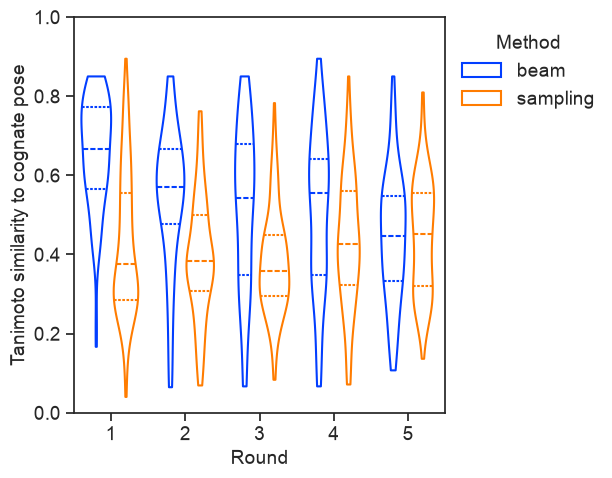

In [63]:
cognate_prolif_fp = fp_with_cognate.to_bitvectors()[0]
not_cognate_prolif_fp = fp_with_cognate.to_bitvectors()[1:]
cognate_binding_pose_similarities = DataStructs.BulkTanimotoSimilarity(cognate_prolif_fp, not_cognate_prolif_fp)
cognate_binding_pose_similarities_df = cognate_and_gen_ligands_with_docking_poses_df.iloc[1:][["method", "round"]]
cognate_binding_pose_similarities_df["tanimoto_similarity"] = cognate_binding_pose_similarities
plt.figure(figsize=(6, 5))
sns.violinplot(data=cognate_binding_pose_similarities_df, y="tanimoto_similarity", x="round", inner="quartile", hue="method", fill=False, cut=0)
plt.legend(loc="upper right", bbox_to_anchor=(1.45, 1), title="Method")
plt.ylabel("Tanimoto similarity to cognate pose")
plt.xticks(range(5), range(1, 6))
plt.xlabel("Round")
plt.ylim(0, 1);